<h1 style="text-align: center; color: #1A5276; font-weight: bold;">Construcción y análisis del SPI (Standarized Precipitation Index)</h1>

En este notebook se realiza la construccion y análisis del SPI (**IPE - Índice de Precipitación Estandarizado**) con base en datos de la precipitación, proveniente de CHIRPS, sucedida entre 1982 y 2025 en el departamento de Caldas.

El análisis desarrollado permite:

- Evaluar el SPI como indicador de sequía  
- Analizar su comportamiento en diferentes escalas temporales  
- Simular reglas de pago tipo seguro paramétrico  
- Identificar configuraciones óptimas para diseño del índice  

Este desarrollo constituye la base para la calibración del SPI mediante su integración con modelos de producción.

<h2 style="text-align: left; color: green; font-weight: bold;">Preliminares</h2>

Acciones antes de iniciar el desarrollo del algoritmo

In [3]:
# ============================================================
# PROYECTO MIAD - Cálculo, clasificación, validación y pago SPI
# Fuente: CHIRPS mensual
# Unidad: departamento - año - mes
# ============================================================

# ============================================================
# 1. Librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gamma, norm

pd.options.display.float_format = "{:.3f}".format

<h2 style="text-align: left; color: green; font-weight: bold;">Funciones</h2>

Se definen funciones reutilizables que estructuran el análisis y soportan tanto la construcción del índice SPI como la formulación del esquema paramétrico de pago. Estas funciones encapsulan la lógica del modelo, permitiendo su reutilización, facilitando la trazabilidad y asegurando consistencia en todo el flujo analítico.

Las principales funciones implementadas son:

- **Cálculo del SPI (`calcular_spi_gamma`)**  
  Ajusta una distribución Gamma a la precipitación acumulada y transforma la probabilidad acumulada a una distribución normal estándar, permitiendo obtener el índice SPI en diferentes ventanas temporales.

- **Clasificación del SPI (tabla oficial y recurrencia)**  
  Permite categorizar los valores del SPI en niveles climáticos (normal, sequía leve, moderada, severa, etc.), facilitando la interpretación del índice y su comparación con estándares climáticos.

- **Métricas de clasificación (`calcular_metricas_clasificacion`)**  
  Calcula indicadores como Precision, Recall, F1, F2, tasas de error y exactitud, utilizados para evaluar la capacidad del SPI de representar eventos de sequía conocidos.

- **Función de pago lineal (`pago_lineal_spi`)**  
  Define una relación entre el valor del SPI y una proporción de pago (entre 0 y 1), basada en parámetros de *trigger* y *exit*, como base para la simulación del esquema paramétrico.

- **Función de pago híbrido (`pago_hibrido_spi`)**  
  Implementa el esquema paramétrico multiescala, donde:
  - SPI-9 determina la activación del evento  
  - SPI-6 define la intensidad del pago  

  Esta función integra la lógica final del modelo, separando la detección de eventos de la medición de su severidad.

---

### 🔍 Nota técnica

La modularidad de estas funciones permite:

- Reutilizar la lógica en diferentes etapas del análisis  
- Ajustar parámetros sin modificar la estructura del código  
- Facilitar la validación, calibración y extensión del modelo  

---

> Estas funciones constituyen la base operativa del modelo paramétrico propuesto.

In [5]:
# ============================================================
# 2. Funciones
# ============================================================

# ------------------------------------------------------------
# 2.1. Función SPI Gamma
# ------------------------------------------------------------

def calcular_spi_gamma(serie):
    """
    Calcula SPI ajustando una distribución Gamma a los valores positivos
    y transformando la probabilidad acumulada a una normal estándar.

    Conserva el índice original:
    - Los NaN originales quedan como NaN.
    - Los valores positivos reciben SPI.
    - Los valores cero reciben SPI según la probabilidad de ocurrencia de ceros.
    """

    resultado = pd.Series(index=serie.index, dtype=float)

    datos = serie.dropna()

    if len(datos) < 30:
        return resultado

    datos_pos = datos[datos > 0]

    if len(datos_pos) < 10:
        return resultado

    try:
        # Probabilidad de precipitación cero
        q = (datos == 0).sum() / len(datos)

        # Ajuste Gamma solo con valores positivos
        shape, loc, scale = gamma.fit(datos_pos, floc=0)

        # CDF para valores positivos, corregida por probabilidad de cero
        cdf_pos = gamma.cdf(datos_pos, shape, loc=loc, scale=scale)
        cdf_pos = q + (1 - q) * cdf_pos

        # SPI para valores positivos
        cdf_pos = np.clip(cdf_pos, 1e-6, 1 - 1e-6)
        resultado.loc[datos_pos.index] = norm.ppf(cdf_pos)

        # SPI para valores cero
        datos_cero = datos[datos == 0]

        if len(datos_cero) > 0:
            cdf_cero = np.clip(q, 1e-6, 1 - 1e-6)
            resultado.loc[datos_cero.index] = norm.ppf(cdf_cero)

    except Exception:
        resultado.loc[datos.index] = np.nan

    return resultado


# ------------------------------------------------------------
# 2.2. Clasificación SPI según tabla oficial de valores normalizados
# ------------------------------------------------------------

def clasificar_spi_oficial(x):
    """
    Clasificación estándar del SPI.
    """
    if pd.isna(x):
        return np.nan
    elif x >= 2.0:
        return "Extremadamente húmedo"
    elif x >= 1.5:
        return "Muy húmedo"
    elif x >= 1.0:
        return "Moderadamente húmedo"
    elif x > -1.0:
        return "Normal"
    elif x > -1.5:
        return "Moderadamente seco"
    elif x > -2.0:
        return "Severamente seco"
    else:
        return "Extremadamente seco"


# ------------------------------------------------------------
# 2.3. Clasificación SPI según tabla oficial de probabilidad de recurrencia
# ------------------------------------------------------------

def clasificar_spi_recurrencia(x):
    """
    Clasificación enfocada en sequía según tabla de recurrencia.
    Nota: esta tabla trata valores entre 0 y -0.99 como sequía leve.
    """
    if pd.isna(x):
        return np.nan
    elif x <= -2.0:
        return "Sequía extrema"
    elif x <= -1.5:
        return "Sequía severa"
    elif x <= -1.0:
        return "Sequía moderada"
    elif x < 0.0:
        return "Sequía leve"
    else:
        return "Sin sequía"
    
    
# ------------------------------------------------------------
# 2.4. Función de métricas de clasificación
# ------------------------------------------------------------

def calcular_metricas_clasificacion(real, pred):
    """
    Calcula métricas de clasificación binaria.
    real: 0/1
    pred: 0/1
    """

    real = pd.Series(real).astype(int)
    pred = pd.Series(pred).astype(int)

    tp = ((pred == 1) & (real == 1)).sum()
    fp = ((pred == 1) & (real == 0)).sum()
    fn = ((pred == 0) & (real == 1)).sum()
    tn = ((pred == 0) & (real == 0)).sum()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    f2 = 5 * precision * recall / (4 * precision + recall + 1e-6)

    tasa_fn = fn / (fn + tp + 1e-6)
    tasa_fp = fp / (fp + tn + 1e-6)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-6)

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "Tasa_FN": tasa_fn,
        "Tasa_FP": tasa_fp,
        "Accuracy": accuracy,
        "Meses_activados": pred.sum(),
        "Proporcion_activada": pred.mean()
    }


# ------------------------------------------------------------
# 2.5. Función de pago lineal con trigger y exit
# ------------------------------------------------------------

def pago_lineal_spi(spi, trigger=-1.0, exit=-2.0):
    """
    Función de pago lineal.
    
    Si SPI >= trigger: pago = 0
    Si SPI <= exit: pago = 1
    Si exit < SPI < trigger: pago proporcional entre 0 y 1
    """

    if pd.isna(spi):
        return np.nan

    if spi >= trigger:
        return 0.0
    elif spi <= exit:
        return 1.0
    else:
        return (trigger - spi) / (trigger - exit)


# ------------------------------------------------------------
# 2.6. Función final de pago híbrido SPI-9 + SPI-6
# ------------------------------------------------------------

def pago_hibrido_spi(spi9, spi6,
                     trigger_spi9,
                     trigger_spi6,
                     exit_spi6):
    """
    Pago híbrido:
    - SPI-9 activa el evento.
    - SPI-6 define la proporción de pago.
    """

    if pd.isna(spi9) or pd.isna(spi6):
        return np.nan

    # 1. Activación con SPI-9
    if spi9 > trigger_spi9:
        return 0.0

    # 2. Intensidad con SPI-6
    if spi6 >= trigger_spi6:
        return 0.0

    if spi6 <= exit_spi6:
        return 1.0

    return (trigger_spi6 - spi6) / (trigger_spi6 - exit_spi6)

<h2 style="text-align: left; color: green; font-weight: bold;">Preliminares</h2>

Parámetros y lectura de fuentes de datos, requeridos para la ejecución del algoritmo.

<h3 style="text-align: left; color: blue; font-weight: bold;">Parámetros</h3>

Se establecen los parámetros del análisis:

- Rutas de los archivos de entrada (CHIRPS y eventos base)  
- Departamento de análisis (Caldas)  
- Ventanas temporales del SPI (1, 3, 6, 9 y 12 meses)  
- Parámetros de la función de pago (trigger y exit)  

Esta sección centraliza las configuraciones para facilitar ajustes posteriores.

In [8]:
# ============================================================
# 3. Parámetros generales
# ============================================================

ARCHIVO_CHIRPS = "df_chirps_mensual_caldas_cauca.csv"
ARCHIVO_EVENTOS_BASE = "eventos_base_SPI.xlsx"

DEPARTAMENTO_ANALISIS = "Caldas"

VENTANAS_SPI = [1, 3, 6, 9, 12]

# Periodos conocidos de sequía.

# Parámetros iniciales para simulación de pago.
# Por ahora se usan como regla genérica; luego se pueden calibrar.
TRIGGER_SPI = -1.0    # comienza pago
EXIT_SPI = -2.0       # pago máximo

<h3 style="text-align: left; color: blue; font-weight: bold;">Lectura y preparación de la información</h3>

Se realiza la carga y validación de los datos:

- Lectura del archivo de precipitación (CHIRPS)  
- Construcción de la variable fecha a partir de año y mes  
- Ordenamiento temporal de los datos  

Adicionalmente:

- Se carga el archivo de eventos base previamente construido  
- Se convierten las fechas a formato datetime  
- Se estructura la lista de eventos de sequía para su uso posterior  

Finalmente, se realiza una validación exploratoria de los datos.

In [10]:
# ============================================================
# 4. Lectura y preparación de la información
# ============================================================

# ------------------------------------------------------------
# 4.1. Archivo CHIRPS
# ------------------------------------------------------------

dfWork = pd.read_csv(ARCHIVO_CHIRPS)

dfWork["fecha"] = pd.to_datetime(
    dict(year=dfWork ["year"], month=dfWork ["month"], day=1)
)

dfWork = dfWork .sort_values(["departamento", "fecha"]).reset_index(drop=True)

print('Revisión inicial del Dataframe')
display(dfWork.head())
display(dfWork.info())
display(dfWork.groupby("departamento").agg(
    fecha_min=("fecha", "min"),
    fecha_max=("fecha", "max"),
    n_meses=("fecha", "count"),
    precip_min=("chirps_precip_mm", "min"),
    precip_max=("chirps_precip_mm", "max")
))

# ------------------------------------------------------------
# 4.2. Archivo eventos
# ------------------------------------------------------------

dfEventosBase = pd.read_excel(
    ARCHIVO_EVENTOS_BASE,
    sheet_name="eventos_base"
)

dfEventosBase["inicio_evento"] = pd.to_datetime(dfEventosBase["inicio_evento"])
dfEventosBase["fin_evento"] = pd.to_datetime(dfEventosBase["fin_evento"])

# Convertir al formato usado por el código anterior
eventos_sequia = list(
    dfEventosBase[["inicio_evento", "fin_evento"]]
    .itertuples(index=False, name=None)
)

print("Número de eventos cargados:", len(eventos_sequia))
display(dfEventosBase.head())

Revisión inicial del Dataframe


,departamento,year,month,chirps_precip_mm,fecha
0,Caldas,1981,1,83.888,1981-01-01
1,Caldas,1981,2,196.020,1981-02-01
2,Caldas,1981,3,209.910,1981-03-01
3,Caldas,1981,4,349.242,1981-04-01
4,Caldas,1981,5,418.138,1981-05-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1084 entries, 0 to 1083
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   departamento      1084 non-null   object        
 1   year              1084 non-null   int64         
 2   month             1084 non-null   int64         
 3   chirps_precip_mm  1084 non-null   float64       
 4   fecha             1084 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 42.5+ KB


None

,fecha_min,fecha_max,n_meses,precip_min,precip_max
departamento,,,,,
Caldas,1981-01-01,2026-02-01,542,31.473,637.939
Cauca,1981-01-01,2026-02-01,542,85.529,627.361


Número de eventos cargados: 9


,inicio_evento,fin_evento,ventanas_precip,percentiles,tipos_evento_base,duracion_meses
0,1985-04-01,1985-08-01,"1,6",15,B_NO_ENSO,5
1,1992-04-01,1992-12-01,"9,12",15,A_ENSO,9
2,1997-07-01,1998-10-01,"3,6,9,12,18",15,A_ENSO,16
3,2001-04-01,2001-12-01,"6,9,12",15,A_ENSO,9
4,2002-06-01,2002-09-01,18,15,A_ENSO,4


<h3 style="text-align: left; color: purple; font-weight: bold;">Análisis y conclusiones</h3>

<h4 style="text-align: left; color: grey; font-weight: bold;">Estructura y calidad del dataset</h4>

Se cargó la información de precipitación mensual proveniente de CHIRPS, estructurada a nivel de departamento.  
El dataset incluye las variables:

- `departamento`
- `year`
- `month`
- `chirps_precip_mm`
- `fecha` (construida a partir de año y mes)

Se verificó que:

- No existen valores nulos en ninguna de las variables  
- Los tipos de datos son consistentes (numéricos y fechas correctamente definidos)  
- La variable `fecha` permite una indexación temporal adecuada  

Esto garantiza que la base es consistente y apta para análisis temporal.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Cobertura temporal</h4>

El dataset cubre el periodo:

- **Inicio:** enero de 1981  
- **Fin:** febrero de 2026  
- **Total:** 542 meses por departamento  

Esta cobertura permite:

- Capturar múltiples ciclos climáticos (incluyendo eventos ENSO)  
- Ajustar distribuciones estadísticas de forma robusta  
- Reducir sesgos asociados a ventanas cortas de observación  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Cobertura espacial</h4>

El dataset contiene información para múltiples departamentos, incluyendo:

- **Caldas** (departamento objeto de estudio)  
- **Cauca** (disponible como referencia)

El análisis posterior se centra en Caldas, permitiendo:

- Consistencia en la evaluación del índice  
- Coherencia con la definición de eventos climáticos  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Caracterización de la precipitación</h4>

Se analizaron rangos de precipitación para validar consistencia:

- Caldas:
  - Mínimo: ~31 mm
  - Máximo: ~638 mm

- Cauca:
  - Mínimo: ~86 mm
  - Máximo: ~627 mm

Estos rangos evidencian:

- Alta variabilidad climática  
- Ausencia de valores atípicos evidentes  
- Idoneidad para modelamiento probabilístico mediante distribución Gamma  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Carga de eventos climáticos base</h4>

Se cargó un conjunto de **9 eventos climáticos**, previamente construidos a partir del comportamiento de la precipitación en Caldas.

Cada evento contiene:

- `inicio_evento` y `fin_evento`
- `duracion_meses`
- `ventanas_precip` (escalas temporales relevantes)
- `percentiles` (criterios de selección)
- `tipos_evento_base` (clasificación ENSO / NO ENSO)

Los eventos presentan:

- Duraciones variables (aprox. 4 a 16 meses)  
- Diferentes configuraciones de acumulación (1, 3, 6, 9, 12, 18 meses)  
- Diferenciación entre eventos asociados y no asociados a ENSO  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Consideraciones metodológicas</h4>

Los eventos utilizados no corresponden a registros observados de impacto o reclamaciones, sino a una **construcción analítica basada en precipitación**, lo que implica que:

- Funcionan como referencia para calibración del índice  
- Incorporan criterios hidrológicos (duración, acumulación, intensidad)  
- Permiten evaluar el desempeño del SPI bajo diferentes escalas temporales  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Conclusiones del bloque</h4>

La información cargada presenta:

- Consistencia estructural y temporal  
- Cobertura suficiente para análisis estadístico robusto  
- Representatividad climática adecuada  

Adicionalmente, la definición previa de eventos climáticos proporciona una base sólida para:

- Evaluar el comportamiento del SPI  
- Comparar diferentes ventanas temporales  
- Diseñar y calibrar esquemas paramétricos basados en precipitación  

En conjunto, este bloque deja preparada la información para la fase de transformación y cálculo del índice SPI.

<h2 style="text-align: left; color: green; font-weight: bold;">Transformación del dataset</h2>

Se construyen las variables clave del análisis:

- **Cálculo de precipitación acumulada** para cada ventana temporal  
- **Cálculo del SPI** por ventana, considerando estacionalidad (agrupación por mes)  

Posteriormente:

- Se filtra el departamento de análisis (Caldas)  
- Se construye la variable binaria de eventos conocidos de sequía  
- Se clasifica el SPI según:
  - tabla oficial (umbrales estándar)
  - tabla de recurrencia (enfoque probabilístico)  

Finalmente:

- Se construyen variables binarias de activación del SPI según cada criterio  

In [13]:
# ============================================================
# 5. Transformación del dataset
# ============================================================

# ------------------------------------------------------------
# 5.1. Cálculo de acumulados y SPI 1, 3, 6, 9 y 12
# ------------------------------------------------------------

for k in VENTANAS_SPI:

    dfWork[f"precip_{k}"] = (
        dfWork .groupby("departamento")["chirps_precip_mm"]
          .rolling(window=k, min_periods=k)
          .sum()
          .reset_index(level=0, drop=True)
    )

    dfWork[f"spi_{k}"] = (
        dfWork.groupby(["departamento", "month"])[f"precip_{k}"]
          .transform(calcular_spi_gamma)
    )

cols_spi = [f"spi_{k}" for k in VENTANAS_SPI]

print('\nRevisión del Dataframe con el SPI en diferentes ventanas de tiempo')
display(dfWork[["departamento", "fecha", "chirps_precip_mm"] + cols_spi].head(15))
display(dfWork[cols_spi].describe())


# ------------------------------------------------------------
# 5.2. Filtrar departamento de análisis
# ------------------------------------------------------------

df_dep = dfWork[dfWork["departamento"] == DEPARTAMENTO_ANALISIS].copy()
df_dep = df_dep.sort_values("fecha").reset_index(drop=True)

print('\nRevisión Dataframe para Caldas')
display(df_dep[["fecha"] + cols_spi].head())


# ------------------------------------------------------------
# 5.3. Construcción de eventos conocidos de sequía
# ------------------------------------------------------------

df_dep["evento_sequia_conocido"] = 0

for inicio, fin in eventos_sequia:

    inicio = pd.to_datetime(inicio)
    fin = pd.to_datetime(fin)

    mask = (
        (df_dep["fecha"] >= inicio) &
        (df_dep["fecha"] <= fin)
    )

    df_dep.loc[mask, "evento_sequia_conocido"] = 1

print('\nRevisión del Dataframe con eventos de sequia')
display(df_dep["evento_sequia_conocido"].value_counts(normalize=True))


# ------------------------------------------------------------
# 5.4. Clasificación según tabla de probabilidad / recurrencia
# ------------------------------------------------------------

for k in VENTANAS_SPI:
    df_dep[f"cat_oficial_spi_{k}"] = df_dep[f"spi_{k}"].apply(clasificar_spi_oficial)
    df_dep[f"cat_recurrencia_spi_{k}"] = df_dep[f"spi_{k}"].apply(clasificar_spi_recurrencia)

print('\nRevisión del Dataframe con clasificación de eventos')
display(df_dep[
    ["fecha"] +
    [f"spi_{k}" for k in VENTANAS_SPI] +
    [f"cat_oficial_spi_{k}" for k in VENTANAS_SPI]
].head(15))


# ------------------------------------------------------------
# 5.5. Construcción de variables binarias de clasificación
# ------------------------------------------------------------

for k in VENTANAS_SPI:

    # Criterio oficial: sequía inicia en SPI <= -1
    df_dep[f"evento_spi_{k}_oficial"] = (
        df_dep[f"spi_{k}"] <= -1.0
    ).astype(int)

    # Criterio recurrencia: sequía leve o peor inicia en SPI < 0
    df_dep[f"evento_spi_{k}_recurrencia"] = (
        df_dep[f"spi_{k}"] < 0.0
    ).astype(int)


Revisión del Dataframe con el SPI en diferentes ventanas de tiempo


,departamento,fecha,chirps_precip_mm,spi_1,spi_3,spi_6,spi_9,spi_12
0,Caldas,1981-01-01,83.888,-1.158,NaN,NaN,NaN,NaN
1,Caldas,1981-02-01,196.020,0.313,NaN,NaN,NaN,NaN
2,Caldas,1981-03-01,209.910,-0.481,-0.548,NaN,NaN,NaN
3,Caldas,1981-04-01,349.242,0.800,0.268,NaN,NaN,NaN
4,Caldas,1981-05-01,418.138,1.683,0.986,NaN,NaN,NaN
5,Caldas,1981-06-01,307.409,1.353,1.999,0.818,NaN,NaN
6,Caldas,1981-07-01,154.192,-0.050,1.586,1.172,NaN,NaN
7,Caldas,1981-08-01,245.827,0.727,0.954,1.245,NaN,NaN
8,Caldas,1981-09-01,251.611,-0.100,0.257,1.348,0.779,NaN
9,Caldas,1981-10-01,341.056,0.008,0.316,1.052,0.930,NaN


,spi_1,spi_3,spi_6,spi_9,spi_12
count,1084.000,1080.000,1074.000,1068.000,1062.000
mean,0.000,0.000,0.000,0.000,0.000
std,1.001,1.000,1.000,1.000,1.000
min,-3.374,-3.157,-3.120,-2.961,-2.806
25%,-0.632,-0.680,-0.698,-0.687,-0.683
50%,0.006,0.049,0.001,-0.008,-0.061
75%,0.660,0.669,0.668,0.731,0.714
max,4.003,3.137,3.305,2.687,2.348



Revisión Dataframe para Caldas


,fecha,spi_1,spi_3,spi_6,spi_9,spi_12
0,1981-01-01,-1.158,NaN,NaN,NaN,NaN
1,1981-02-01,0.313,NaN,NaN,NaN,NaN
2,1981-03-01,-0.481,-0.548,NaN,NaN,NaN
3,1981-04-01,0.800,0.268,NaN,NaN,NaN
4,1981-05-01,1.683,0.986,NaN,NaN,NaN



Revisión del Dataframe con eventos de sequia


evento_sequia_conocido
0   0.806
1   0.194
Name: proportion, dtype: float64


Revisión del Dataframe con clasificación de eventos


,fecha,spi_1,spi_3,spi_6,spi_9,spi_12,cat_oficial_spi_1,cat_oficial_spi_3,cat_oficial_spi_6,cat_oficial_spi_9,cat_oficial_spi_12
0,1981-01-01,-1.158,NaN,NaN,NaN,NaN,Moderadamente seco,NaN,NaN,NaN,NaN
1,1981-02-01,0.313,NaN,NaN,NaN,NaN,Normal,NaN,NaN,NaN,NaN
2,1981-03-01,-0.481,-0.548,NaN,NaN,NaN,Normal,Normal,NaN,NaN,NaN
3,1981-04-01,0.800,0.268,NaN,NaN,NaN,Normal,Normal,NaN,NaN,NaN
4,1981-05-01,1.683,0.986,NaN,NaN,NaN,Muy húmedo,Normal,NaN,NaN,NaN
5,1981-06-01,1.353,1.999,0.818,NaN,NaN,Moderadamente húmedo,Muy húmedo,Normal,NaN,NaN
6,1981-07-01,-0.050,1.586,1.172,NaN,NaN,Normal,Muy húmedo,Moderadamente húmedo,NaN,NaN
7,1981-08-01,0.727,0.954,1.245,NaN,NaN,Normal,Normal,Moderadamente húmedo,NaN,NaN
8,1981-09-01,-0.100,0.257,1.348,0.779,NaN,Normal,Normal,Moderadamente húmedo,Normal,NaN
9,1981-10-01,0.008,0.316,1.052,0.930,NaN,Normal,Normal,Moderadamente húmedo,Normal,NaN


<h3 style="text-align: left; color: purple; font-weight: bold;">Análisis</h3>

<h4 style="text-align: left; color: grey; font-weight: bold;">Construcción del SPI en múltiples ventanas</h4>

A partir de la serie de precipitación mensual, se construyeron acumulados móviles para diferentes ventanas temporales:

- SPI-1 (mensual)
- SPI-3 (trimestral)
- SPI-6 (semestral)
- SPI-9
- SPI-12 (anual)

Posteriormente, para cada ventana:

- Se ajustó una **distribución Gamma** a la precipitación acumulada
- Se transformó la probabilidad acumulada a una **distribución normal estándar**, obteniendo el SPI

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comportamiento estadístico del SPI</h4>

Los resultados muestran que:

- El SPI en todas las ventanas presenta:
  - **Media ≈ 0**
  - **Desviación estándar ≈ 1**

Esto confirma que:

- La transformación fue correctamente realizada  
- El índice está estandarizado y es comparable entre ventanas  

Adicionalmente:

- Se observan valores extremos entre:
  - **-3.37 (sequía extrema)**
  - **+4.00 (condiciones extremadamente húmedas)**  

Esto evidencia que  <span style="color: purple; font-weight: bold;">el índice captura adecuadamente eventos severos</span>.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Efecto de las ventanas temporales</h4>

Se observa que:

- Las ventanas más largas (SPI-9, SPI-12):
  - Presentan menor variabilidad extrema  
  - Generan señales más suavizadas  

- Las ventanas cortas (SPI-1, SPI-3):
  - Son más volátiles  
  - Capturan variaciones rápidas de precipitación  

Esto refleja  <span style="color: purple; font-weight: bold;">correctamente la naturaleza del SPI</span>:
- Corto plazo → alta sensibilidad  
- Largo plazo → mayor estabilidad  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Valores faltantes (NaN)</h4>

Se identifican valores NaN al inicio de la serie para ventanas largas:

- SPI-3 requiere al menos 3 meses  
- SPI-6 requiere 6 meses  
- SPI-12 requiere 12 meses  

Estos valores  <span style="color: purple;">no representan errores</span> sino una <span style="color: purple; font-weight: bold;">limitación estructural del cálculo por acumulación</span>

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Construcción del dataset para Caldas</h4>

Se filtró el dataset para el departamento de **Caldas**, obteniendo:

- Serie temporal completa del SPI en todas las ventanas  
- Base consistente para evaluación posterior  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Construcción de la variable de eventos conocidos</h4>

Se creó la variable binaria:

- `evento_sequia_conocido`

Resultados:

- **19.4% del tiempo corresponde a eventos de sequía**
- **80.6% corresponde a condiciones normales**

<span style="color: purple; font-weight: bold;">Esto implica</span>:
- Dataset desbalanceado (lo esperado en fenómenos climáticos)  
- Importancia de usar métricas como Recall y F2 en evaluación  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Clasificación del SPI</h4>

Se clasificaron los valores del SPI según categorías oficiales:

- Extremadamente seco  
- Severamente seco  
- Moderadamente seco  
- Normal  
- Moderadamente húmedo  
- etc.

Esto permite:

- Traducir valores numéricos en interpretaciones climáticas  
- Facilitar análisis comparativo con eventos conocidos  

<h3 style="text-align: left; color: purple; font-weight: bold;">Hallazgos relevantes</h3>

<h5 style="text-align: left; color: grey; font-weight: bold;">Validación estadística del SPI</h5>
El comportamiento (media 0, desviación 1) confirma que el cálculo es **correcto y consistente con la teoría del SPI**.

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Diferencias estructurales entre ventanas</h5>
Las ventanas generan representaciones distintas del fenómeno:

- SPI-1 → ruido climático de corto plazo  
- SPI-12 → señal estructural de sequía  

Esto anticipa que <span style="color: purple; font-weight: bold;">no todas las ventanas tendrán el mismo desempeño</span>:

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Naturaleza desbalanceada del problema</h5>
La baja proporción de eventos de sequía implica que:

- La precisión por sí sola no es suficiente  
- Es necesario priorizar métricas como Recall o F2  

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Base adecuada para evaluación del índice</h5>
El dataset transformado permite:

- Comparar directamente SPI vs eventos  
- Evaluar desempeño por ventana  
- Simular reglas de activación  

<h3 style="text-align: left; color: purple; font-weight: bold;">Conclusiones del bloque</h3>

1. <span style="color:#1E8449; font-weight: bold;">Correcta implementación del SPI</span>

El índice SPI fue calculado adecuadamente, cumpliendo con sus propiedades estadísticas fundamentales (media cero y varianza unitaria).

2. <span style="color:#1E8449; font-weight: bold;">Captura de la variabilidad climática</span>

El SPI refleja tanto eventos extremos como condiciones normales, permitiendo una caracterización completa del comportamiento climático.

3. <span style="color:#1E8449; font-weight: bold;">Diferenciación por escala temporal</span>

Las distintas ventanas del SPI capturan diferentes dinámicas del sistema:

- Corto plazo → alta sensibilidad  
- Largo plazo → mayor estabilidad  

Esto habilita su evaluación como indicador paramétrico.

4. <span style="color:#1E8449; font-weight: bold;">Preparación para evaluación de desempeño</span>

La construcción de la variable de eventos conocidos permite evaluar objetivamente el SPI como herramienta de detección de sequías.

5. <span style="color:#1E8449; font-weight: bold;">Base para diseño paramétrico</span>

El dataset transformado constituye la base para:

- Evaluación del desempeño del SPI  
- Simulación de esquemas de pago  
- Selección de ventanas óptimas  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resumen general</h4>

> Se construyó un dataset transformado robusto, donde el SPI fue correctamente estimado en múltiples escalas temporales, permitiendo capturar la variabilidad climática y habilitando su evaluación como indicador para el diseño de esquemas paramétricos.

<h2 style="text-align: left; color: green; font-weight: bold;">Clasificación</h2>

Se evalúa el desempeño del SPI como indicador de sequía:

- Se calculan métricas de clasificación para cada ventana y criterio:
  - Precision
  - Recall
  - F1
  - F2
  - tasas de error  

- Se analizan las distribuciones de categorías del SPI dentro y fuera de eventos  

- Se generan gráficos comparativos para evaluar el desempeño por ventana  

- Se visualiza el comportamiento temporal del SPI frente a los eventos conocidos  

Esta sección permite identificar qué ventana SPI se alinea mejor con los eventos reales.


Revisión del Dataframe con métricas de clasificación


,SPI,Criterio,Precision,Recall,F1,F2,Tasa_FN,Tasa_FP,Accuracy,TP,FP,FN,TN,Meses_activados,Proporcion_activada
6,SPI-9,oficial,0.811,0.695,0.749,0.716,0.305,0.039,0.910,73,17,32,420,90,0.166
8,SPI-12,oficial,0.866,0.676,0.759,0.707,0.324,0.025,0.917,71,11,34,426,82,0.151
4,SPI-6,oficial,0.699,0.552,0.617,0.577,0.448,0.057,0.867,58,25,47,412,83,0.153
2,SPI-3,oficial,0.562,0.476,0.515,0.491,0.524,0.089,0.827,50,39,55,398,89,0.164
0,SPI-1,oficial,0.415,0.324,0.364,0.339,0.676,0.110,0.780,34,48,71,389,82,0.151
9,SPI-12,recurrencia,0.371,0.971,0.537,0.734,0.029,0.396,0.675,102,173,3,264,275,0.507
7,SPI-9,recurrencia,0.369,0.943,0.531,0.719,0.057,0.387,0.677,99,169,6,268,268,0.494
5,SPI-6,recurrencia,0.339,0.876,0.489,0.666,0.124,0.410,0.646,92,179,13,258,271,0.500
3,SPI-3,recurrencia,0.328,0.819,0.469,0.630,0.181,0.403,0.640,86,176,19,261,262,0.483
1,SPI-1,recurrencia,0.259,0.667,0.373,0.507,0.333,0.458,0.566,70,200,35,237,270,0.498



Distribución clasificación oficial - SPI-1


,Fuera_evento,Dentro_evento
cat_oficial_spi_1,,
Extremadamente húmedo,0.023,0.010
Extremadamente seco,0.021,0.086
Moderadamente húmedo,0.128,0.029
Moderadamente seco,0.069,0.133
Muy húmedo,0.037,0.019
Normal,0.703,0.619
Severamente seco,0.021,0.105



Distribución clasificación oficial - SPI-3


...

,Fuera_evento,Dentro_evento
cat_oficial_spi_6,,
Extremadamente húmedo,0.023,0.000
Extremadamente seco,0.000,0.152
Moderadamente húmedo,0.111,0.000
Moderadamente seco,0.056,0.229
Muy húmedo,0.069,0.000
Normal,0.738,0.448
Severamente seco,0.002,0.171



Distribución clasificación oficial - SPI-9


,Fuera_evento,Dentro_evento
cat_oficial_spi_9,,
Extremadamente húmedo,0.023,0.000
Extremadamente seco,0.000,0.114
Moderadamente húmedo,0.135,0.000
Moderadamente seco,0.040,0.429
Muy húmedo,0.056,0.000
Normal,0.746,0.305
Severamente seco,0.000,0.152



Distribución clasificación oficial - SPI-12


,Fuera_evento,Dentro_evento
cat_oficial_spi_12,,
Extremadamente húmedo,0.021,0.000
Extremadamente seco,0.000,0.114
Moderadamente húmedo,0.115,0.000
Moderadamente seco,0.026,0.371
Muy húmedo,0.087,0.000
Normal,0.751,0.324
Severamente seco,0.000,0.190


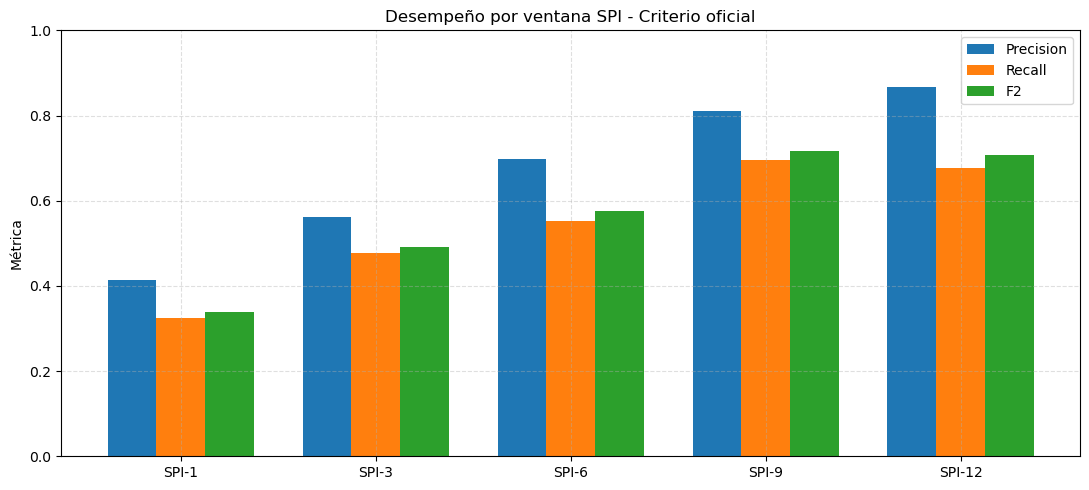

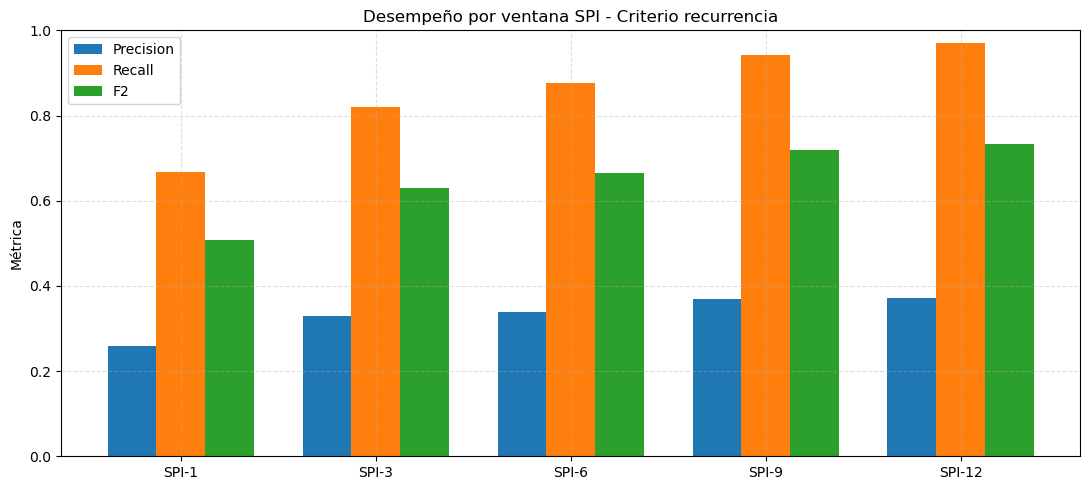

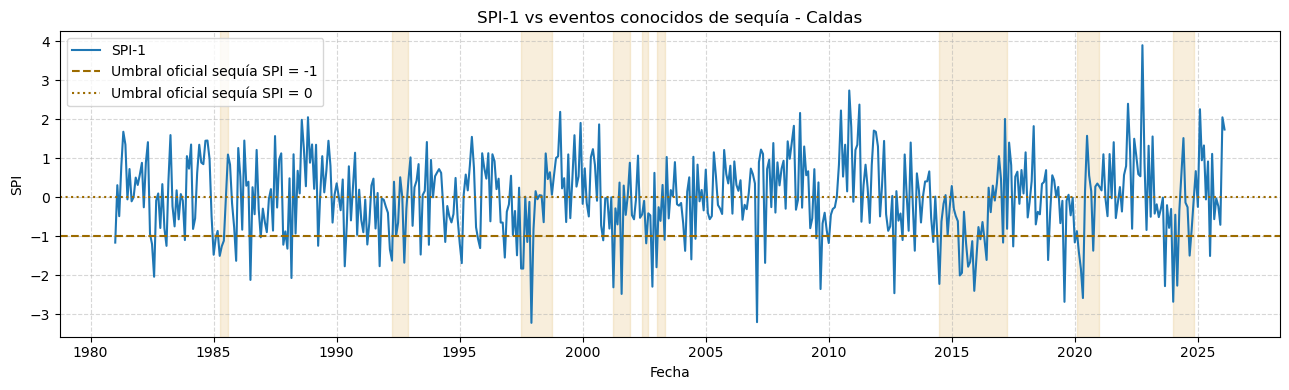

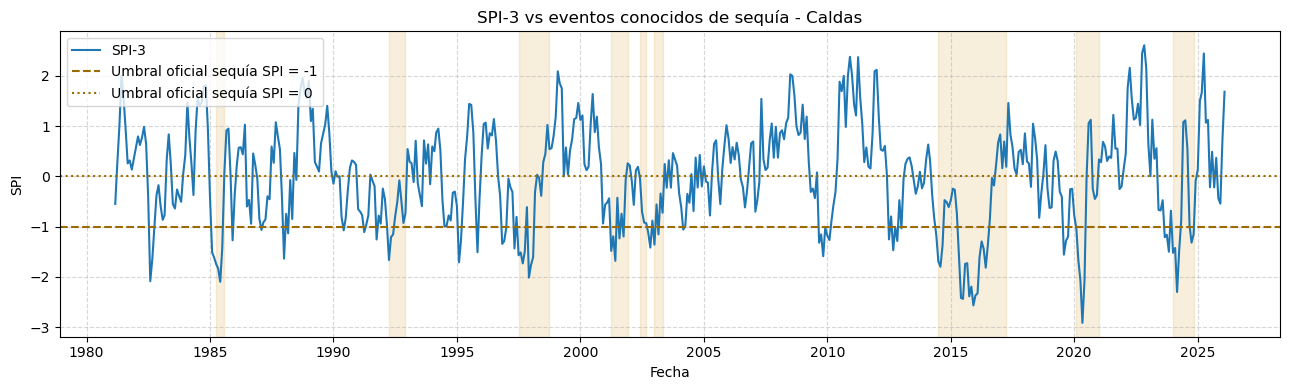

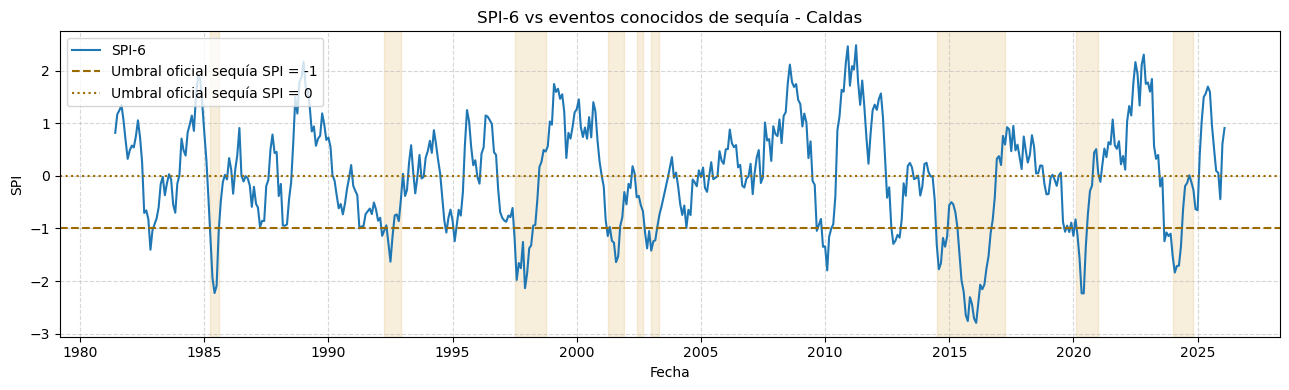

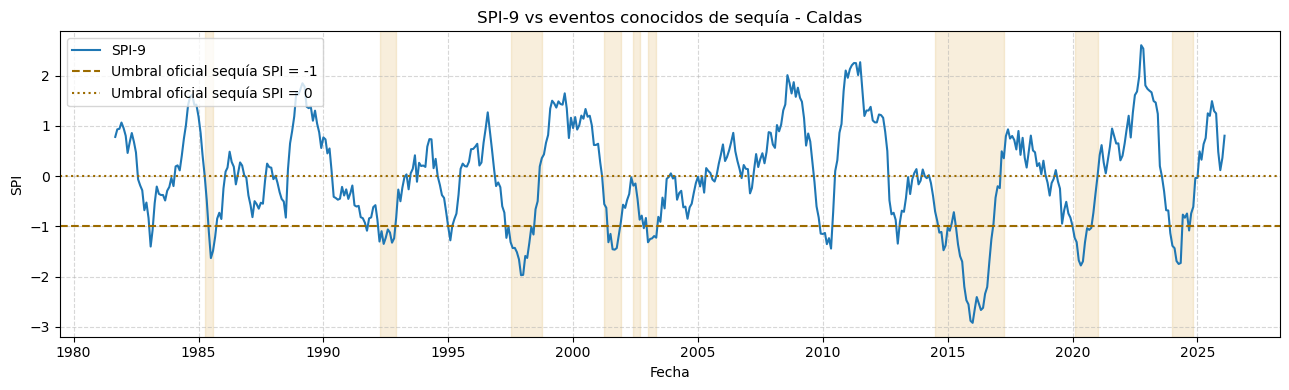

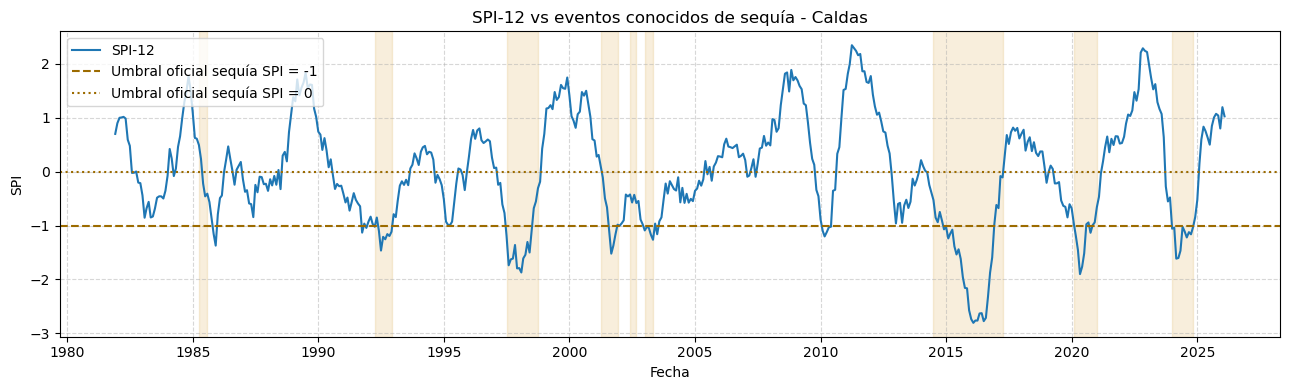

In [18]:
# ============================================================
# 6. Clasificación
# ============================================================

# ------------------------------------------------------------
# 6.1. Métricas por ventana SPI y por criterio
# ------------------------------------------------------------

resultados_metricas = []

for k in VENTANAS_SPI:

    for criterio in ["oficial", "recurrencia"]:

        pred_col = f"evento_spi_{k}_{criterio}"

        metricas = calcular_metricas_clasificacion(
            real=df_dep["evento_sequia_conocido"],
            pred=df_dep[pred_col]
        )

        metricas["SPI"] = f"SPI-{k}"
        metricas["Ventana"] = k
        metricas["Criterio"] = criterio

        resultados_metricas.append(metricas)

df_metricas = pd.DataFrame(resultados_metricas)

cols_orden = [
    "SPI", "Criterio",
    "Precision", "Recall", "F1", "F2",
    "Tasa_FN", "Tasa_FP",
    "Accuracy",
    "TP", "FP", "FN", "TN",
    "Meses_activados", "Proporcion_activada"
]

df_metricas = df_metricas[cols_orden]

print('\nRevisión del Dataframe con métricas de clasificación')
display(df_metricas.sort_values(["Criterio", "F2"], ascending=[True, False]))


# ------------------------------------------------------------
# 6.2. Distribución de categorías SPI dentro y fuera de sequías conocidas
# ------------------------------------------------------------

tablas_categorias = {}

for k in VENTANAS_SPI:

    tabla = pd.crosstab(
        df_dep[f"cat_oficial_spi_{k}"],
        df_dep["evento_sequia_conocido"],
        normalize="columns"
    )

    tabla.columns = ["Fuera_evento", "Dentro_evento"]
    tablas_categorias[f"SPI-{k}"] = tabla

    print(f"\nDistribución clasificación oficial - SPI-{k}")
    display(tabla)


# ------------------------------------------------------------
# 6.3. Gráfico de desempeño comparativo por ventana SPI
# ------------------------------------------------------------

for criterio in ["oficial", "recurrencia"]:

    df_plot = df_metricas[df_metricas["Criterio"] == criterio].copy()

    x = np.arange(len(df_plot))
    width = 0.25

    plt.figure(figsize=(11, 5))

    plt.bar(x - width, df_plot["Precision"], width, label="Precision")
    plt.bar(x, df_plot["Recall"], width, label="Recall")
    plt.bar(x + width, df_plot["F2"], width, label="F2")

    plt.xticks(x, df_plot["SPI"])
    plt.ylim(0, 1)
    plt.title(f"Desempeño por ventana SPI - Criterio {criterio}")
    plt.ylabel("Métrica")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6.4. Gráfico temporal SPI por ventana con eventos conocidos
# ------------------------------------------------------------

for k in VENTANAS_SPI:

    plt.figure(figsize=(13, 4))

    for inicio, fin in eventos_sequia:
        plt.axvspan(
            pd.to_datetime(inicio),
            pd.to_datetime(fin),
            color="#D9A441",
            alpha=0.18
        )

    plt.plot(
        df_dep["fecha"],
        df_dep[f"spi_{k}"],
        label=f"SPI-{k}",
        linewidth=1.5
    )
  
    plt.axhline(
    -1.0,
    color="#9C6B00",
    linestyle="--",
    label="Umbral oficial sequía SPI = -1"
    )

    plt.axhline(
    0.0,
    color="#9C6B00",
    linestyle=":",
    label="Umbral oficial sequía SPI = 0"
    )

    plt.title(f"SPI-{k} vs eventos conocidos de sequía - {DEPARTAMENTO_ANALISIS}")
    plt.xlabel("Fecha")
    plt.ylabel("SPI")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

<h3 style="text-align: left; color: purple; font-weight: bold;">Análisis</h3>

<h4 style="text-align: left; color: grey; font-weight: bold;">Definición de criterios de clasificación</h4>
Se evaluaron dos enfoques para identificar eventos de sequía a partir del SPI:

#### 🔹 Criterio oficial
- Basado en umbrales estándar del SPI:
  - Sequía: SPI ≤ -1
- Representa la definición climatológica tradicional

#### 🔹 Criterio de recurrencia
- Basado en percentiles de la distribución histórica
- Permite controlar la frecuencia de activación

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Evaluación de desempeño por ventana SPI</h4>

Se evaluaron las ventanas SPI-1, SPI-3, SPI-6, SPI-9 y SPI-12 usando:

- **Precision**
- **Recall**
- **F2-score** (prioriza Recall)

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resultados – Criterio oficial</h4>

Se observa una mejora consistente al aumentar la ventana temporal:

- SPI-1 → bajo desempeño (ruido alto)
- SPI-3 → mejora moderada
- SPI-6 → desempeño intermedio
- **SPI-9 → balance óptimo**
- SPI-12 → mayor precisión pero menor sensibilidad marginal

<span style="color:#1E8449; font-weight: bold;">Hallazgos clave</span>:

- **Precision aumenta con la ventana**  
- **Recall también mejora, pero con rendimientos decrecientes después de SPI-9**
- **F2 se estabiliza en SPI-9 y SPI-12**

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:
- SPI-9 logra el mejor equilibrio entre detección (Recall) y control de falsos positivos (Precision)

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resultados – Criterio de recurrencia</h4>
- Recall muy alto (>0.9 en SPI-9 y SPI-12)
- Precision muy baja (~0.37)


<span style="color:#1E8449; font-weight: bold;">Hallazgos</span>:
- Se activan demasiados meses (~50% del tiempo)
- Alto número de falsos positivos

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:
- Este criterio es útil como referencia estadística  
- Pero **no es viable para diseño operativo o financiero**

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Frecuencia de activación</h4>

| Ventana | Criterio oficial | Criterio recurrencia |
|--------|----------------|---------------------|
| Activación | ~15% | ~50% |

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

- El criterio oficial genera una frecuencia razonable y controlada  
- El criterio de recurrencia sobre-activa el sistema  

Esto es <span style="color:#1F618D; font-weight: bold;">crítico en diseño de seguros</span>:
- Evitar pagos excesivos  
- Mantener sostenibilidad financiera  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Análisis de distribución por categorías SPI</h4>

Se evaluó cómo se distribuyen las categorías del SPI dentro y fuera de eventos:

<span style="color:#1E8449; font-weight: bold;">Hallazgos clave</span>:

1. **Categorías secas (moderado, severo, extremo)**:
   - Se concentran claramente dentro de eventos de sequía  
   - Esta separación mejora con ventanas largas (SPI-6, SPI-9, SPI-12)

2. **Categoría "Normal"**:
   - Predomina fuera de eventos  
   - Reduce su presencia dentro de eventos a medida que aumenta la ventana  

3. **Categorías húmedas**:
   - Prácticamente no aparecen dentro de eventos  

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:
- El SPI sí discrimina correctamente condiciones de sequía  
- Y esta capacidad mejora con ventanas más largas  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Análisis temporal (series SPI vs eventos)</h4>

Al comparar las series temporales:

- SPI-1:
  - Alta volatilidad  
  - Muchas falsas activaciones  

- SPI-3:
  - Menor ruido, pero aún inestable  

- SPI-6:
  - Mejor alineación con eventos  

- **SPI-9:**
  - Mejor correspondencia con eventos conocidos  
  - Señales claras y sostenidas  

- SPI-12:
  - Muy suave  
  - Puede retrasar o diluir señales  

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:
- SPI-9 logra capturar la dinámica real de los eventos  
- Sin introducir ruido excesivo ni perder sensibilidad  

<h3 style="text-align: left; color: purple; font-weight: bold;">Hallazgos críticos</h3>

<h5 style="text-align: left; color: grey; font-weight: bold;">El SPI es altamente dependiente de la escala temporal</h5>
La ventana define completamente el comportamiento del índice.

---

<h5 style="text-align: left; color: grey; font-weight: bold;">El criterio de recurrencia no es viable operativamente</h5>
Aunque maximiza Recall, genera una activación excesiva.

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Existe un trade-off estructural:</h5>
- Ventanas cortas → ruido  
- Ventanas largas → pérdida de sensibilidad  

---

<h5 style="text-align: left; color: grey; font-weight: bold;">SPI-9 emerge como punto de equilibrio</h5>
- Buen Recall  
- Alta Precision  
- Frecuencia de activación controlada  
- Buena alineación temporal  

<h3 style="text-align: left; color: purple; font-weight: bold;">Conclusiones del bloque</h3>

1. <span style="color:#1E8449; font-weight: bold;">Validez del SPI como indicador</span>

El SPI demuestra capacidad para discriminar eventos de sequía frente a condiciones normales.

2. <span style="color:#1E8449; font-weight: bold;">Importancia de la ventana temporal</span>

La selección de la ventana es el factor más crítico en el desempeño del índice.

3. <span style="color:#1E8449; font-weight: bold;">Limitaciones del enfoque basado en recurrencia</span> 

El criterio de recurrencia, aunque útil para exploración, no es adecuado para implementación práctica.

4. <span style="color:#1E8449; font-weight: bold;">Selección de SPI-9 como ventana óptima</span> 

SPI-9 ofrece el mejor balance entre:

- Detección de eventos  
- Control de falsas alarmas  
- Coherencia temporal  

5. <span style="color:#1E8449; font-weight: bold;">Base para diseño del esquema paramétrico</span> 

La selección de SPI-9 permite avanzar hacia:

- Definición de triggers  
- Diseño de funciones de pago  
- Integración con modelos de producción  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resumen general</h4>

> Se evaluó el desempeño del SPI en múltiples ventanas y criterios de clasificación, identificando que SPI-9 bajo el criterio oficial proporciona el mejor balance entre precisión, capacidad de detección y estabilidad temporal, constituyéndose como la base para el diseño del esquema paramétrico.

<h2 style="text-align: left; color: green; font-weight: bold;">Simulación de pago</h2>

Se construye una simulación conceptual del comportamiento de un seguro paramétrico:

#### Pago mensual
Se calcula, para cada ventana SPI, una proporción de pago basada en la función lineal definida.

#### Liquidación por evento
Para cada evento climático:

- Se analizan los valores del SPI dentro del evento  
- Se calculan métricas de severidad:
  - SPI mínimo, promedio y mediano  
  - pago máximo, promedio y mediano  
  - proporción de meses con pago  

Esto permite evaluar la afectación a nivel de evento, no solo mensual.

#### Resumen de pagos
Se generan estadísticas agregadas por ventana SPI.

#### Comparación dentro vs fuera de evento
Se analiza el comportamiento del pago en:
- periodos de sequía
- periodos sin sequía  

Esto permite identificar sobrepagos y omisiones.

#### Visualización (boxplots)
Se analizan distribuciones de:
- severidad máxima por evento  
- severidad promedio por evento  

#### Resumen estadístico
Se consolidan indicadores de liquidación por ventana SPI.

#### Gráficos temporales
Se visualiza el comportamiento del pago a lo largo del tiempo.

#### Selección de mejor ventana
Se identifica la ventana SPI con mejor desempeño (según F2) y se visualiza su comportamiento.


Revisión del Dataframe con pagos


,fecha,spi_1,spi_3,spi_6,spi_9,spi_12,pago_spi_1,pago_spi_3,pago_spi_6,pago_spi_9,pago_spi_12
0,1981-01-01,-1.158,NaN,NaN,NaN,NaN,0.158,NaN,NaN,NaN,NaN
1,1981-02-01,0.313,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN
2,1981-03-01,-0.481,-0.548,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN
3,1981-04-01,0.800,0.268,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN
4,1981-05-01,1.683,0.986,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN
5,1981-06-01,1.353,1.999,0.818,NaN,NaN,0.000,0.000,0.000,NaN,NaN
6,1981-07-01,-0.050,1.586,1.172,NaN,NaN,0.000,0.000,0.000,NaN,NaN
7,1981-08-01,0.727,0.954,1.245,NaN,NaN,0.000,0.000,0.000,NaN,NaN
8,1981-09-01,-0.100,0.257,1.348,0.779,NaN,0.000,0.000,0.000,0.000,NaN
9,1981-10-01,0.008,0.316,1.052,0.930,NaN,0.000,0.000,0.000,0.000,NaN



Liquidación por evento climático


,inicio_evento,fin_evento,duracion_evento_meses,SPI,ventana_spi,spi_min_evento,spi_prom_evento,spi_mediana_evento,pago_max_evento,pago_prom_evento,pago_mediana_evento,meses_con_pago,proporcion_meses_con_pago
0,1985-04-01,1985-08-01,5,SPI-1,1,-1.498,-0.563,-1.112,0.498,0.173,0.112,3,0.600
1,1985-04-01,1985-08-01,5,SPI-3,3,-2.099,-1.406,-1.741,1.000,0.600,0.741,4,0.800
2,1985-04-01,1985-08-01,5,SPI-6,6,-2.228,-1.698,-1.938,1.000,0.635,0.938,5,1.000
3,1985-04-01,1985-08-01,5,SPI-9,9,-1.632,-0.940,-1.111,0.632,0.246,0.111,3,0.600
4,1985-04-01,1985-08-01,5,SPI-12,12,-0.458,-0.071,-0.221,0.000,0.000,0.000,0,0.000
5,1992-04-01,1992-12-01,9,SPI-1,1,-1.673,-0.429,-0.293,0.673,0.144,0.000,2,0.222
6,1992-04-01,1992-12-01,9,SPI-3,3,-1.664,-0.841,-0.799,0.664,0.115,0.000,3,0.333
7,1992-04-01,1992-12-01,9,SPI-6,6,-1.631,-0.981,-0.939,0.631,0.121,0.000,4,0.444
8,1992-04-01,1992-12-01,9,SPI-9,9,-1.350,-1.172,-1.228,0.350,0.192,0.228,8,0.889
9,1992-04-01,1992-12-01,9,SPI-12,12,-1.464,-1.152,-1.159,0.464,0.169,0.159,8,0.889



Resumen de pagos por ventana SPI


,SPI,Pago_promedio,Pago_mediano,Pago_max,Meses_con_pago,Proporcion_meses_con_pago,Pago_total_simulado
0,SPI-1,0.076,0.000,1.000,82,0.151,41.106
1,SPI-3,0.080,0.000,1.000,89,0.164,43.191
2,SPI-6,0.074,0.000,1.000,83,0.153,39.562
3,SPI-9,0.070,0.000,1.000,90,0.166,37.495
4,SPI-12,0.064,0.000,1.000,82,0.151,34.021



Comparación de pagos dentro y fuera de eventos conocidos


,SPI,Pago_promedio_dentro_evento,Pago_promedio_fuera_evento,Pago_total_dentro_evento,Pago_total_fuera_evento,Proporcion_pago_dentro_evento,Proporcion_pago_fuera_evento
0,SPI-1,0.193,0.048,20.227,20.879,0.324,0.110
1,SPI-3,0.296,0.028,31.033,12.158,0.476,0.089
2,SPI-6,0.332,0.011,34.834,4.728,0.552,0.057
3,SPI-9,0.326,0.008,34.226,3.269,0.695,0.039
4,SPI-12,0.311,0.003,32.680,1.341,0.676,0.025


C:\Users\Óscar Javier Sánchez\AppData\Local\Temp\ipykernel_79508\1772941812.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_max, labels=[f"SPI-{k}" for k in VENTANAS_SPI], showmeans=True)
C:\Users\Óscar Javier Sánchez\AppData\Local\Temp\ipykernel_79508\1772941812.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_prom, labels=[f"SPI-{k}" for k in VENTANAS_SPI], showmeans=True)


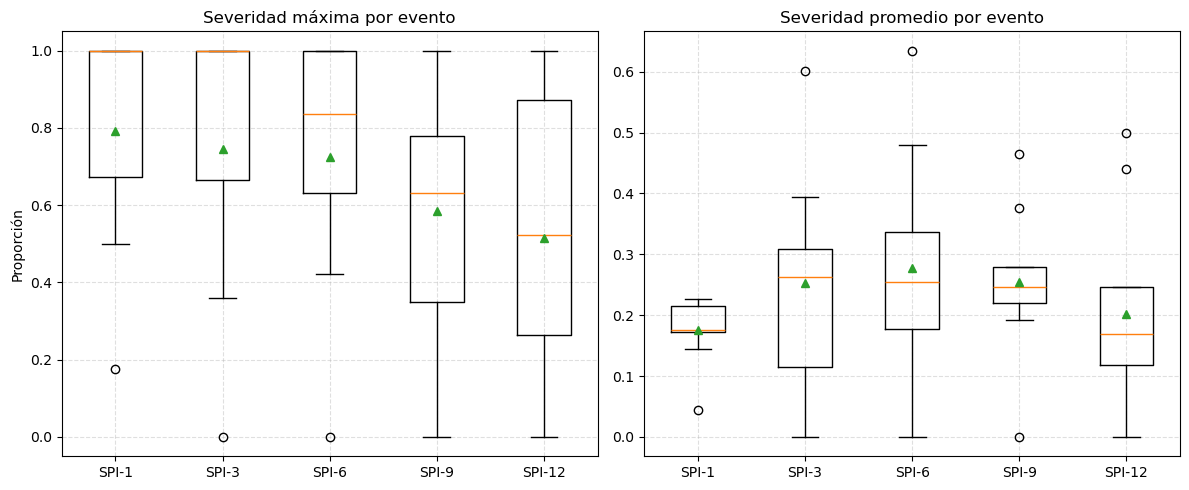


Resumen de liquidación por evento


,SPI,eventos,pago_promedio,pago_mediana,pago_p75,pago_maximo,meses_con_pago_prom,prop_meses_con_pago_prom,ventana_spi
0,SPI-1,9,0.793,1.000,1.000,1.000,3.778,0.326,1
2,SPI-3,9,0.745,1.000,1.000,1.000,5.556,0.446,3
3,SPI-6,9,0.725,0.837,1.000,1.000,6.444,0.520,6
4,SPI-9,9,0.585,0.632,0.778,1.000,8.111,0.656,9
1,SPI-12,9,0.515,0.522,0.871,1.000,7.889,0.595,12


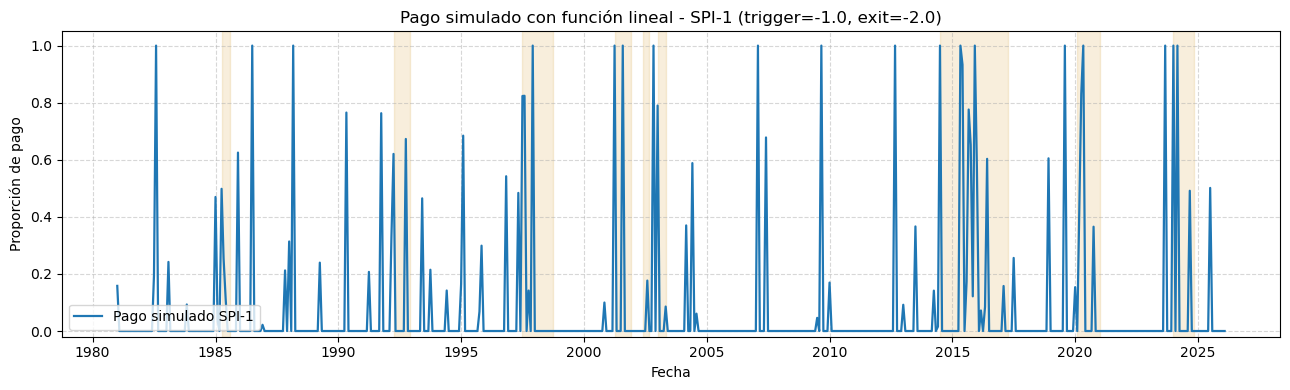

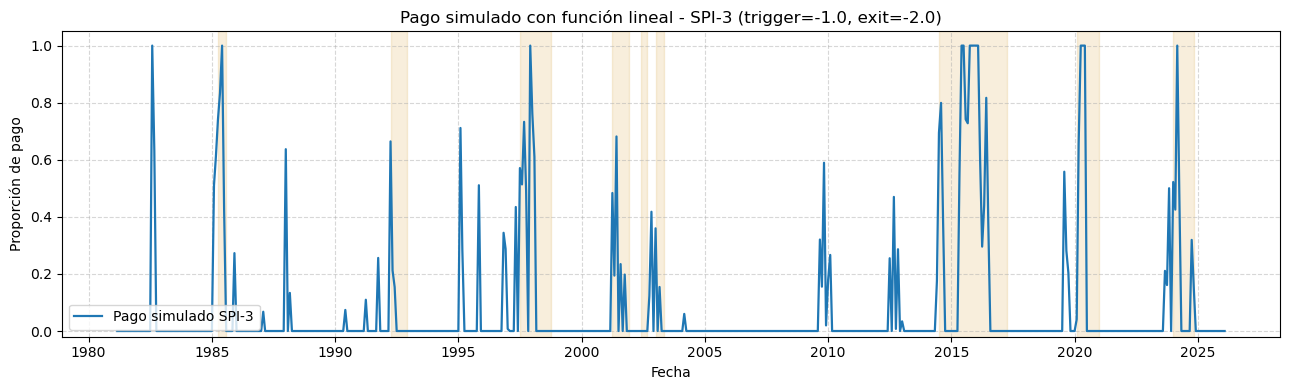

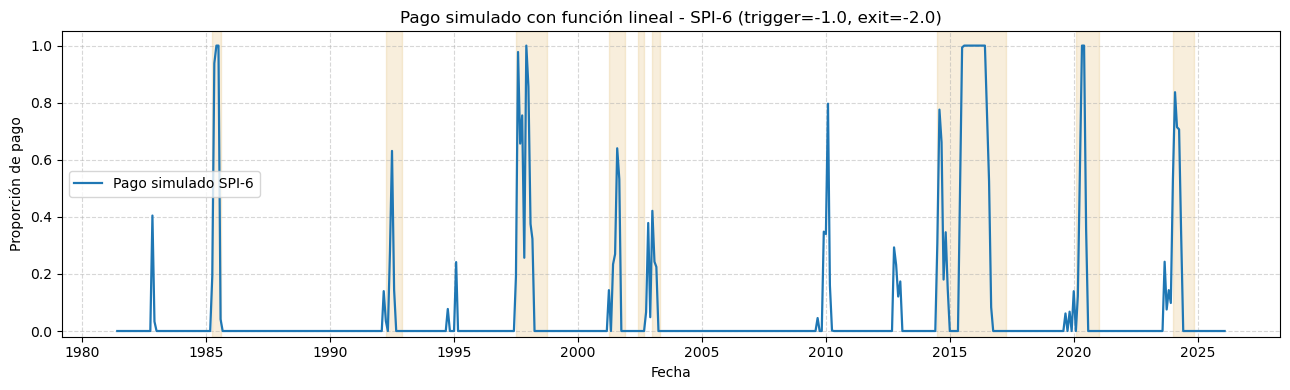

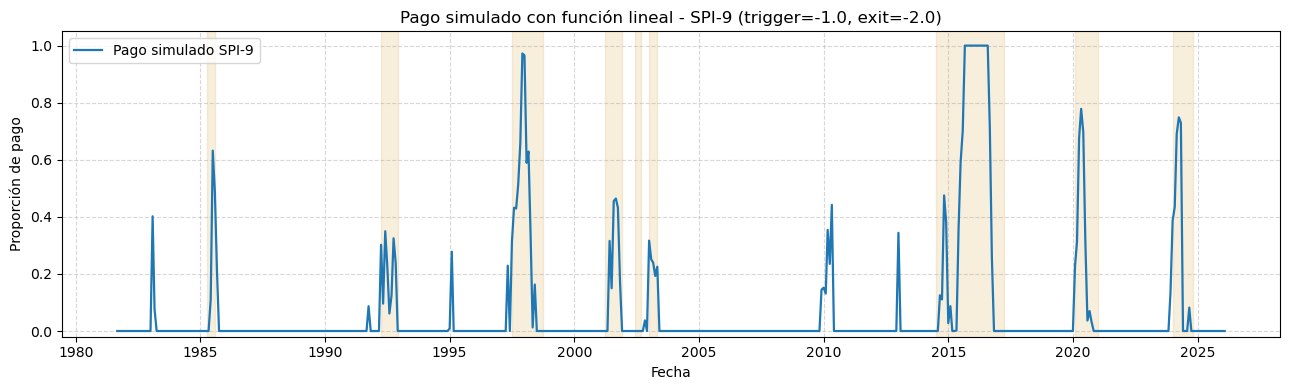

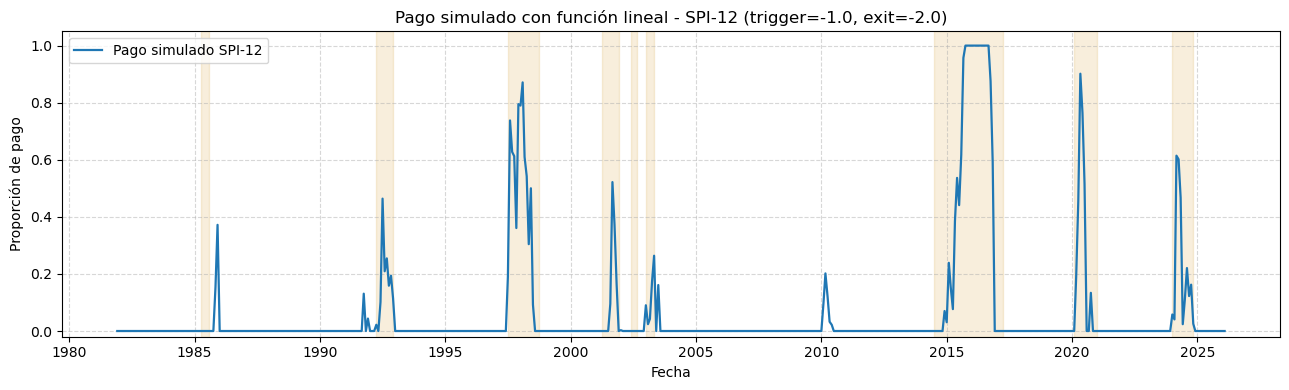

Mejor ventana según F2 - criterio oficial:


SPI                      SPI-9
Criterio               oficial
Precision                0.811
Recall                   0.695
F1                       0.749
F2                       0.716
Tasa_FN                  0.305
Tasa_FP                  0.039
Accuracy                 0.910
TP                          73
FP                          17
FN                          32
TN                         420
Meses_activados             90
Proporcion_activada      0.166
Name: 6, dtype: object

La mejor ventana bajo criterio oficial y F2 es SPI-9, con Precision=0.811, Recall=0.695 y F2=0.716.


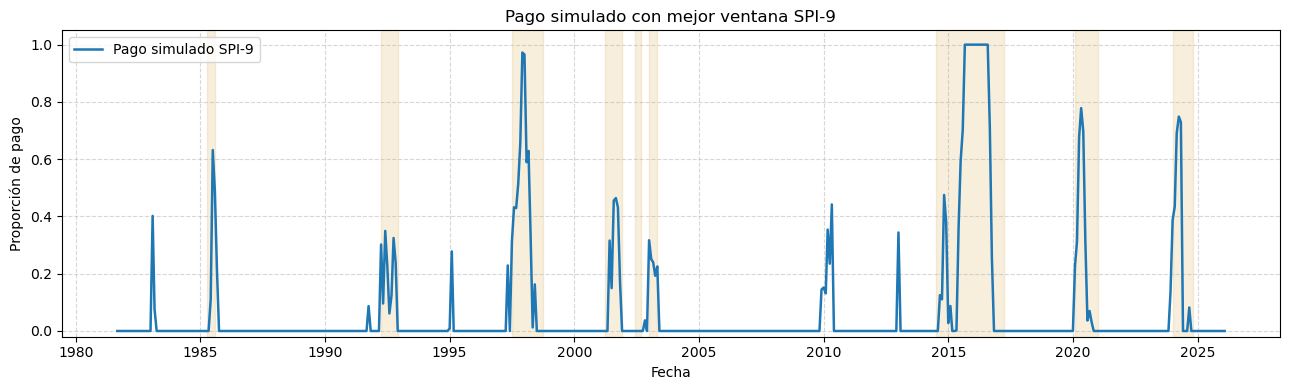

In [23]:
# ============================================================
# 7. Simulación de pago
# ============================================================

# ------------------------------------------------------------
# 7.1. Pago por ventana SPI
# ------------------------------------------------------------

for k in VENTANAS_SPI:

    df_dep[f"pago_spi_{k}"] = df_dep[f"spi_{k}"].apply(
        lambda x: pago_lineal_spi(
            x,
            trigger=TRIGGER_SPI,
            exit=EXIT_SPI
        )
    )

print('\nRevisión del Dataframe con pagos')
display(df_dep[
    ["fecha"] +
    [f"spi_{k}" for k in VENTANAS_SPI] +
    [f"pago_spi_{k}" for k in VENTANAS_SPI]
].head(15))


# ------------------------------------------------------------
# 7.2. Liquidación por evento climático
# ------------------------------------------------------------

pagos_evento = []

for _, evento in dfEventosBase.iterrows():

    inicio = pd.to_datetime(evento["inicio_evento"])
    fin = pd.to_datetime(evento["fin_evento"])

    df_evento = df_dep[
        (df_dep["fecha"] >= inicio) &
        (df_dep["fecha"] <= fin)
    ].copy()

    if df_evento.empty:
        continue

    for k in VENTANAS_SPI:

        col_spi = f"spi_{k}"
        col_pago = f"pago_spi_{k}"

        pagos = df_evento[col_pago].dropna()

        if len(pagos) == 0:
            continue

        pagos_evento.append({
            "inicio_evento": inicio,
            "fin_evento": fin,
            "duracion_evento_meses": len(df_evento),
            "SPI": f"SPI-{k}",
            "ventana_spi": k,

            # Estadísticos SPI dentro del evento
            "spi_min_evento": df_evento[col_spi].min(),
            "spi_prom_evento": df_evento[col_spi].mean(),
            "spi_mediana_evento": df_evento[col_spi].median(),

            # Proporciones liquidadas dentro del evento
            "pago_max_evento": pagos.max(),
            "pago_prom_evento": pagos.mean(),
            "pago_mediana_evento": pagos.median(),
            "meses_con_pago": (pagos > 0).sum(),
            "proporcion_meses_con_pago": (pagos > 0).mean()
        })

dfPagosEvento = pd.DataFrame(pagos_evento)

print("\nLiquidación por evento climático")
display(dfPagosEvento.head(20))


# ------------------------------------------------------------
# 7.3. Resumen de pagos por ventana SPI
# ------------------------------------------------------------

resumen_pagos = []

for k in VENTANAS_SPI:

    col = f"pago_spi_{k}"

    resumen_pagos.append({
        "SPI": f"SPI-{k}",
        "Pago_promedio": df_dep[col].mean(),
        "Pago_mediano": df_dep[col].median(),
        "Pago_max": df_dep[col].max(),
        "Meses_con_pago": (df_dep[col] > 0).sum(),
        "Proporcion_meses_con_pago": (df_dep[col] > 0).mean(),
        "Pago_total_simulado": df_dep[col].sum()
    })

df_resumen_pagos = pd.DataFrame(resumen_pagos)

print('\nResumen de pagos por ventana SPI')
display(df_resumen_pagos)


# ------------------------------------------------------------
# 7.4. Comparación de pagos dentro y fuera de eventos conocidos
# ------------------------------------------------------------

comparacion_pagos_eventos = []

for k in VENTANAS_SPI:

    col = f"pago_spi_{k}"

    dentro = df_dep[df_dep["evento_sequia_conocido"] == 1][col]
    fuera = df_dep[df_dep["evento_sequia_conocido"] == 0][col]

    comparacion_pagos_eventos.append({
        "SPI": f"SPI-{k}",
        "Pago_promedio_dentro_evento": dentro.mean(),
        "Pago_promedio_fuera_evento": fuera.mean(),
        "Pago_total_dentro_evento": dentro.sum(),
        "Pago_total_fuera_evento": fuera.sum(),
        "Proporcion_pago_dentro_evento": (dentro > 0).mean(),
        "Proporcion_pago_fuera_evento": (fuera > 0).mean()
    })

df_comparacion_pagos = pd.DataFrame(comparacion_pagos_eventos)

print('\nComparación de pagos dentro y fuera de eventos conocidos')
display(df_comparacion_pagos)


# ------------------------------------------------------------
# 7.5. Boxplot de proporción liquidada por evento y ventana SPI
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

# --------- BOX 1: severidad máxima ----------
plt.subplot(1, 2, 1)

datos_max = [
    dfPagosEvento[dfPagosEvento["SPI"] == f"SPI-{k}"]["pago_max_evento"].dropna()
    for k in VENTANAS_SPI
]

plt.boxplot(datos_max, labels=[f"SPI-{k}" for k in VENTANAS_SPI], showmeans=True)
plt.title("Severidad máxima por evento")
plt.ylabel("Proporción")
plt.grid(True, linestyle="--", alpha=0.4)


# --------- BOX 2: severidad promedio ----------
plt.subplot(1, 2, 2)

datos_prom = [
    dfPagosEvento[dfPagosEvento["SPI"] == f"SPI-{k}"]["pago_prom_evento"].dropna()
    for k in VENTANAS_SPI
]

plt.boxplot(datos_prom, labels=[f"SPI-{k}" for k in VENTANAS_SPI], showmeans=True)
plt.title("Severidad promedio por evento")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7.6. Resumen estadístico de liquidación por evento
# ------------------------------------------------------------

dfResumenPagosEvento = (
    dfPagosEvento
    .groupby("SPI")
    .agg(
        eventos=("inicio_evento", "count"),
        pago_promedio=("pago_max_evento", "mean"),
        pago_mediana=("pago_max_evento", "median"),
        pago_p75=("pago_max_evento", lambda x: x.quantile(0.75)),
        pago_maximo=("pago_max_evento", "max"),
        meses_con_pago_prom=("meses_con_pago", "mean"),
        prop_meses_con_pago_prom=("proporcion_meses_con_pago", "mean")
    )
    .reset_index()
)

dfResumenPagosEvento["ventana_spi"] = dfResumenPagosEvento["SPI"].str.replace("SPI-", "").astype(int)
dfResumenPagosEvento = dfResumenPagosEvento.sort_values("ventana_spi")

print("\nResumen de liquidación por evento")
display(dfResumenPagosEvento)


# ------------------------------------------------------------
# 7.7. Gráfico temporal de pagos simulados
# ------------------------------------------------------------

for k in VENTANAS_SPI:

    plt.figure(figsize=(13, 4))

    for inicio, fin in eventos_sequia:
        plt.axvspan(
            pd.to_datetime(inicio),
            pd.to_datetime(fin),
            color="#D9A441",
            alpha=0.18
        )

    plt.plot(
        df_dep["fecha"],
        df_dep[f"pago_spi_{k}"],
        label=f"Pago simulado SPI-{k}",
        linewidth=1.6
    )

    plt.title(
        f"Pago simulado con función lineal - SPI-{k} "
        f"(trigger={TRIGGER_SPI}, exit={EXIT_SPI})"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Proporción de pago")
    plt.ylim(-0.02, 1.05)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7.8. Pago simulado combinado: ejemplo con la ventana de mejor F2
# ------------------------------------------------------------

mejor_fila = (
    df_metricas[df_metricas["Criterio"] == "oficial"]
    .sort_values("F2", ascending=False)
    .iloc[0]
)

mejor_k = int(mejor_fila["SPI"].replace("SPI-", ""))

print("Mejor ventana según F2 - criterio oficial:")
display(mejor_fila)

print(
    f"La mejor ventana bajo criterio oficial y F2 es {mejor_fila['SPI']}, "
    f"con Precision={mejor_fila['Precision']:.3f}, "
    f"Recall={mejor_fila['Recall']:.3f} y F2={mejor_fila['F2']:.3f}."
)

df_dep["pago_spi_mejor"] = df_dep[f"pago_spi_{mejor_k}"]

plt.figure(figsize=(13, 4))

for inicio, fin in eventos_sequia:
    plt.axvspan(
        pd.to_datetime(inicio),
        pd.to_datetime(fin),
        color="#D9A441",
        alpha=0.18
    )

plt.plot(
    df_dep["fecha"],
    df_dep["pago_spi_mejor"],
    label=f"Pago simulado SPI-{mejor_k}",
    linewidth=1.8
)

plt.title(f"Pago simulado con mejor ventana SPI-{mejor_k}")
plt.xlabel("Fecha")
plt.ylabel("Proporción de pago")
plt.ylim(-0.02, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<h3 style="text-align: left; color: purple; font-weight: bold;">Análisis</h3>

<h4 style="text-align: left; color: grey; font-weight: bold;">Enfoque de la simulación</h4>

Se implementó un esquema de pago paramétrico basado en el índice SPI, utilizando una función lineal definida por:

- **Trigger:** SPI ≤ -1.0  
- **Exit:** SPI ≤ -2.0  
- **Pago proporcional:**  
  - 0 cuando SPI ≥ -1  
  - 1 cuando SPI ≤ -2  
  - Lineal en el intervalo (-2, -1)

Este esquema permite traducir la severidad del evento climático en una **proporción de pago entre 0 y 1**, evaluada mensualmente.

La simulación se realizó para las ventanas:

- SPI-1, SPI-3, SPI-6, SPI-9 y SPI-12

y se evaluó en términos de:

- Frecuencia de activación
- Severidad de pago (máxima y promedio por evento)
- Coherencia con eventos climáticos conocidos
- Métricas de clasificación

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comportamiento general de los pagos</h4>

Se observa un patrón estructural claro:

- Los pagos son **eventuales y concentrados**, asociados a eventos climáticos extremos
- Existe una alta intermitencia en ventanas cortas (SPI-1 y SPI-3)
- A medida que aumenta la ventana:
  - Los pagos se vuelven más **continuos dentro de eventos**
  - Se reduce la activación fuera de eventos

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

- El esquema captura adecuadamente la naturaleza episódica de la sequía
- La ventana temporal controla directamente la estabilidad del pago

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comparación por ventanas SPI</h4>

##### 🔹 Frecuencia y monto total

- SPI-1 y SPI-3 presentan mayor pago acumulado
- SPI-12 presenta el menor pago total

Sin embargo:

> Un mayor pago acumulado **no implica mejor desempeño**, sino mayor activación (incluyendo ruido)

---

##### 🔹 Activación fuera de eventos (ruido)

| Ventana | Activación fuera de evento |
|--------|--------------------------|
| SPI-1  | 11.0% |
| SPI-3  | 8.9%  |
| SPI-6  | 5.7%  |
| SPI-9  | 3.9%  |
| SPI-12 | 2.5%  |

<span style="color:#1E8449; font-weight: bold;">Hallazgo clave</span>:

> Existe una relación inversa entre ventana y ruido

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comportamiento por evento climático</h4>

A partir del análisis de severidad:

##### 🔹 Severidad máxima

- SPI-1, SPI-3, SPI-6:
  - Alcanzan valores cercanos a 1
  - Capturan picos extremos

- SPI-9, SPI-12:
  - Menor severidad máxima
  - Señales más suavizadas

---

##### 🔹 Severidad promedio

- SPI-1:
  - Baja severidad promedio (~0.17)
  - Eventos fragmentados

- SPI-3 y SPI-6:
  - Mayor severidad promedio (~0.25–0.28)
  - Mejor captura de intensidad acumulada

- SPI-9:
  - Buen balance (~0.25)
  - Menor dispersión

- SPI-12:
  - Menor intensidad (~0.20)
  - Posible subestimación

---

##### 🔹 Persistencia del pago

- SPI cortos:
  - Pagos discontinuos
  - Alta variabilidad temporal

- SPI largos:
  - Pagos más continuos
  - Mejor representación del evento como proceso prolongado

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

> La ventana define si el evento se representa como **picos aislados o procesos continuos**

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Evaluación de desempeño (criterio oficial)</h4>

**Mejor desempeño global:**

> **SPI-9**

| Métrica | Valor |
|--------|------|
| Precision | 0.811 |
| Recall | 0.695 |
| F1 | 0.749 |
| F2 | 0.716 |
| Accuracy | 0.910 |
| Tasa FN | 0.305 |
| Tasa FP | 0.039 |

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

- Alta capacidad de detección (Recall)
- Bajo nivel de falsas alarmas (Precision)
- Balance óptimo según F2 (prioriza Recall)

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Interpretación técnica integral</h4>

##### 🔹 SPI-1 y SPI-3
- Alta sensibilidad
- Alta activación fuera de eventos
- Riesgo de sobrepago
- Representación ruidosa

---

##### 🔹 SPI-12
- Alta estabilidad
- Baja activación espuria
- Pérdida de sensibilidad
- Riesgo de subestimar eventos intensos

---

##### 🔹 SPI-9
- Balance entre:
  - Sensibilidad
  - Especificidad
  - Persistencia temporal
- Representa adecuadamente la dinámica del fenómeno

<h3 style="text-align: left; color: purple; font-weight: bold;">Hallazgos estructurales</h3>

<h5 style="text-align: left; color: grey; font-weight: bold;">Dependencia de la ventana temporal</h5>

La ventana SPI controla:

- Frecuencia de pago
- Intensidad
- Persistencia
- Ruido

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Trade-off fundamental</h5>

| Ventanas cortas | Ventanas largas |
|----------------|----------------|
| Mayor ruido | Menor sensibilidad |
| Pagos fragmentados | Pagos suavizados |
| Mayor activación | Menor activación |

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Naturaleza del pago paramétrico</h5>

El esquema implementado:

- Es consistente con la severidad climática
- Responde proporcionalmente al déficit hídrico
- Mantiene coherencia con eventos observados

<h3 style="text-align: left; color: purple; font-weight: bold;">Conclusiones del bloque</h3>

1. <span style="color:#1E8449; font-weight: bold;">Validez del esquema de pago</span>

La función lineal basada en SPI permite representar adecuadamente la intensidad de la sequía en términos de proporción de pago.

---

2. <span style="color:#1E8449; font-weight: bold;">Impacto crítico de la ventana SPI</span>

La elección de la ventana determina el comportamiento operativo del esquema:

- Activación  
- Persistencia  
- Severidad  

---

3. <span style="color:#1E8449; font-weight: bold;">Limitaciones de ventanas individuales</span>

- SPI-1 / SPI-3:
  - Sobre-reaccionan al ruido  
- SPI-12:
  - Suaviza en exceso los eventos  

---

4. <span style="color:#1E8449; font-weight: bold;">Separación estructural del problema</span>

El análisis evidencia que ninguna ventana SPI optimiza simultáneamente:

- La detección del evento  
- La cuantificación de su intensidad  

---

5. <span style="color:#1E8449; font-weight: bold;">Definición del esquema óptimo combinado</span>

Se establece un esquema híbrido:

- <span style="color:#1F618D; font-weight:bold;">SPI-9 como trigger (activación del evento)</span>  
- <span style="color:#AF601A; font-weight:bold;">SPI-6 como intensidad (nivel de afectación)</span>  

---

6. <span style="color:#1E8449; font-weight: bold;">Justificación técnica</span>

- SPI-9:
  - Minimiza falsos positivos  
  - Captura adecuadamente la ocurrencia del evento  

- SPI-6:
  - Representa mejor la severidad promedio  
  - Captura la dinámica interna del evento  

---

7. <span style="color:#1E8449; font-weight: bold;">Ventaja del enfoque combinado</span>

Este esquema permite:

- Reducir el ruido en la activación  
- Mejorar la representación de la intensidad  
- Disminuir el riesgo base  
- Alinear el índice con la dinámica física del fenómeno  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resumen general</h4>

> La simulación de pagos confirma que la ventana SPI define el comportamiento del esquema paramétrico. Si bien SPI-9 presenta el mejor desempeño global como indicador de activación, la combinación con SPI-6 como medida de intensidad permite construir un esquema más robusto, separando la detección del evento de la cuantificación de su impacto y mejorando significativamente la calidad del diseño del índice.

<h2 style="text-align: left; color: green; font-weight: bold;">Exportación intermedia (modelo base)</h2>

Se exportan los resultados del análisis en archivos CSV:

- Dataset completo con SPI y pagos  
- Métricas de clasificación  
- Resumen de pagos  
- Liquidación por evento  
- Resumen de pagos por evento  

Esto permite reutilizar los resultados y facilitar su análisis externo.

In [28]:
df_dep.to_csv("resultado_spi_multiescala_pago.csv", index=False)
df_metricas.to_csv("metricas_spi_vs_eventos_sequia.csv", index=False)
df_resumen_pagos.to_csv("resumen_pagos_spi.csv", index=False)

print("Archivos exportados:")
print("- resultado_spi_multiescala_pago.csv")
print("- metricas_spi_vs_eventos_sequia.csv")
print("- resumen_pagos_spi.csv")

dfPagosEvento.to_csv("pagos_por_evento_spi.csv", index=False)
dfResumenPagosEvento.to_csv("resumen_pagos_por_evento_spi.csv", index=False)

print("- pagos_por_evento_spi.csv")
print("- resumen_pagos_por_evento_spi.csv")

Archivos exportados:
- resultado_spi_multiescala_pago.csv
- metricas_spi_vs_eventos_sequia.csv
- resumen_pagos_spi.csv
- pagos_por_evento_spi.csv
- resumen_pagos_por_evento_spi.csv


<h2 style="text-align: left; color: green; font-weight: bold;">Ajuste de umbrales SPI</h2>

Con base en el comportamiento observado de los umbrales, se realiza un ajuste de los umbrales para mejorar la precisión de los pagos.


Top 15 umbrales individuales según F2


,ventana_spi,SPI,umbral,TP,FP,FN,TN,Precision,Recall,F1,F2,Tasa_FN,Tasa_FP,Accuracy,Meses_activados,Proporcion_activada
388,12,SPI-12,-0.400,97,93,8,344,0.511,0.924,0.658,0.795,0.076,0.213,0.814,190,0.351
389,12,SPI-12,-0.375,97,96,8,341,0.503,0.924,0.651,0.791,0.076,0.220,0.808,193,0.356
382,12,SPI-12,-0.550,91,66,14,371,0.580,0.867,0.695,0.789,0.133,0.151,0.852,157,0.290
383,12,SPI-12,-0.525,92,72,13,365,0.561,0.876,0.684,0.788,0.124,0.165,0.843,164,0.303
378,12,SPI-12,-0.650,87,46,18,391,0.654,0.829,0.731,0.787,0.171,0.105,0.882,133,0.245
387,12,SPI-12,-0.425,95,89,10,348,0.516,0.905,0.657,0.786,0.095,0.204,0.817,184,0.339
381,12,SPI-12,-0.575,89,57,16,380,0.610,0.848,0.709,0.786,0.152,0.130,0.865,146,0.269
380,12,SPI-12,-0.600,88,52,17,385,0.629,0.838,0.718,0.786,0.162,0.119,0.873,140,0.258
390,12,SPI-12,-0.350,97,101,8,336,0.490,0.924,0.640,0.785,0.076,0.231,0.799,198,0.365
379,12,SPI-12,-0.625,87,49,18,388,0.640,0.829,0.722,0.782,0.171,0.112,0.876,136,0.251


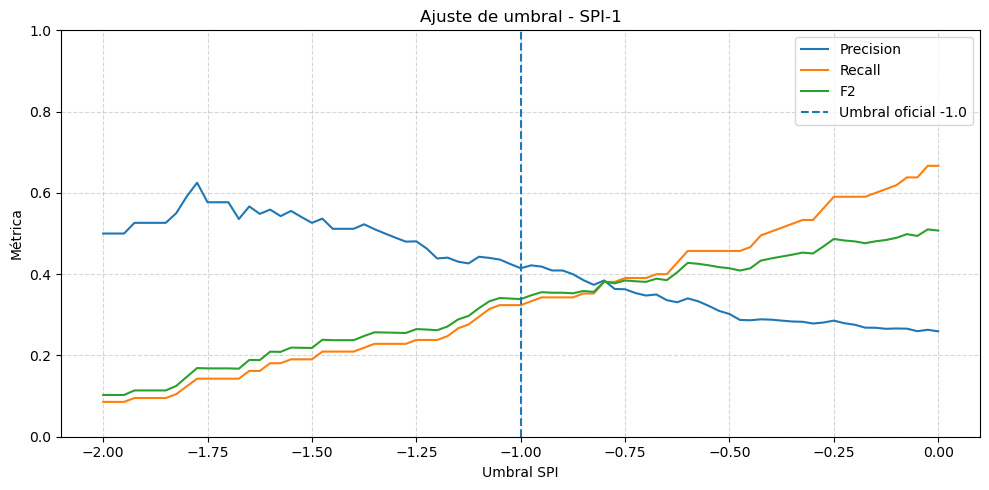

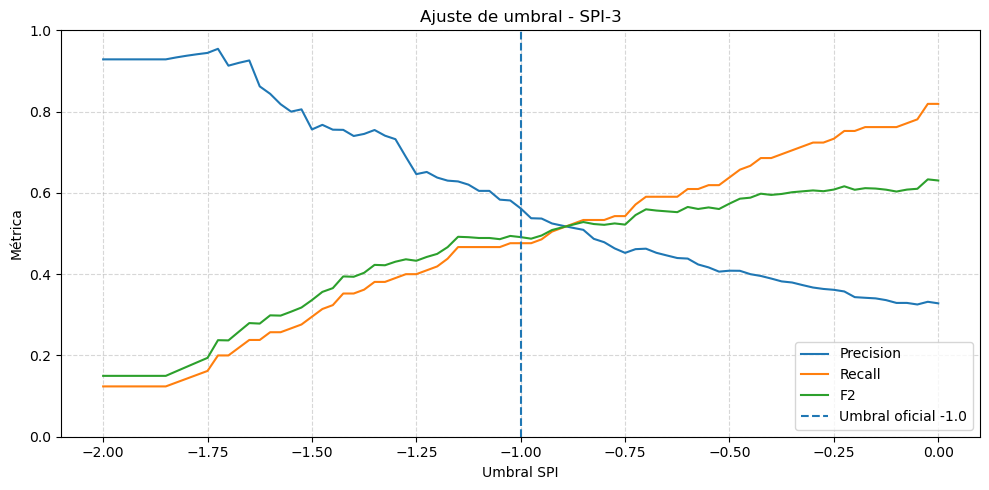

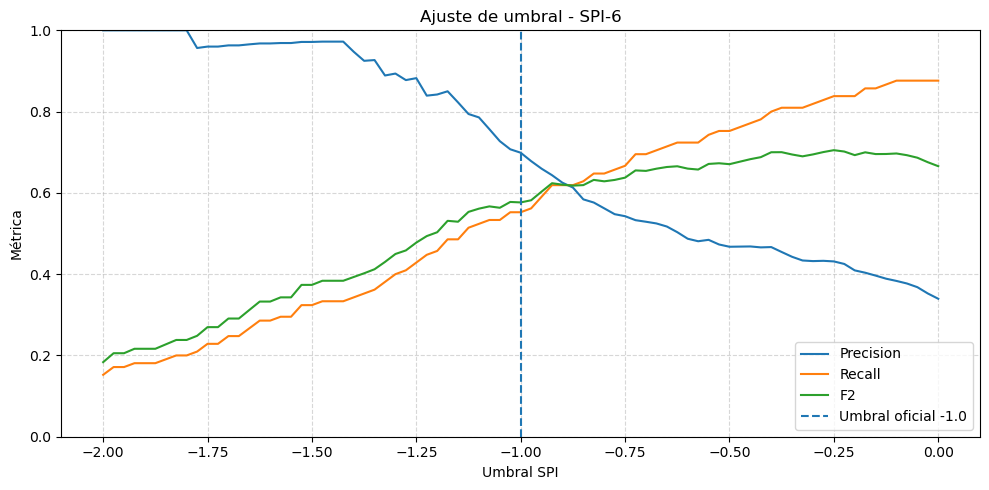

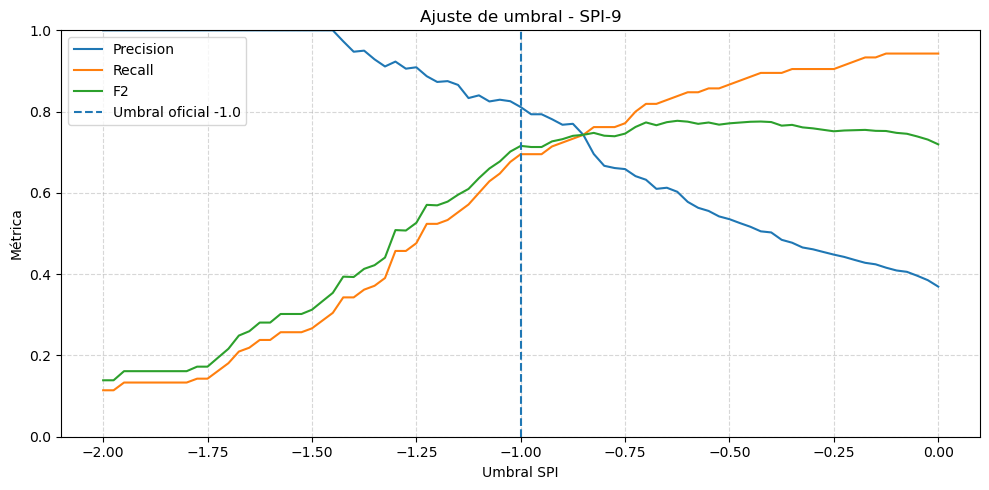

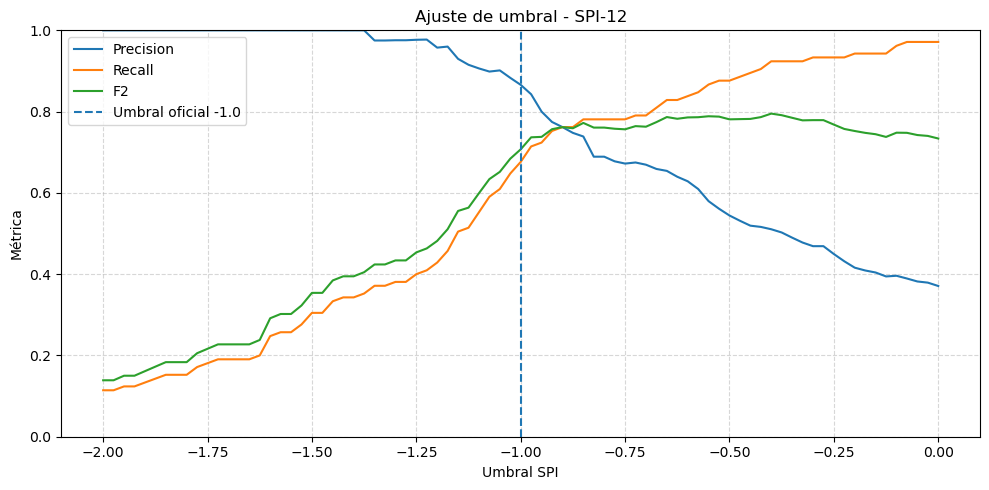


Top 15 combinaciones según F2


,spi_trigger,spi_intensidad,umbral_trigger,umbral_intensidad,TP,FP,FN,TN,Precision,Recall,F1,F2,Tasa_FN,Tasa_FP,Accuracy,Meses_activados,Proporcion_activada
1613,9,6,-0.700,-0.094,84,48,21,389,0.636,0.800,0.709,0.761,0.200,0.110,0.873,132,0.244
1616,9,6,-0.700,0.000,84,49,21,388,0.632,0.800,0.706,0.759,0.200,0.112,0.871,133,0.245
1614,9,6,-0.700,-0.062,84,49,21,388,0.632,0.800,0.706,0.759,0.200,0.112,0.871,133,0.245
1615,9,6,-0.700,-0.031,84,49,21,388,0.632,0.800,0.706,0.759,0.200,0.112,0.871,133,0.245
1760,9,6,-0.625,-0.094,85,55,20,382,0.607,0.810,0.694,0.759,0.190,0.126,0.862,140,0.258
1809,9,6,-0.600,-0.094,86,61,19,376,0.585,0.819,0.683,0.758,0.181,0.140,0.852,147,0.271
1761,9,6,-0.625,-0.062,85,56,20,381,0.603,0.810,0.691,0.758,0.190,0.128,0.860,141,0.260
1907,9,6,-0.550,-0.094,87,68,18,369,0.561,0.829,0.669,0.757,0.171,0.156,0.841,155,0.286
1762,9,6,-0.625,-0.031,85,57,20,380,0.599,0.810,0.688,0.756,0.190,0.130,0.858,142,0.262
1763,9,6,-0.625,0.000,85,57,20,380,0.599,0.810,0.688,0.756,0.190,0.130,0.858,142,0.262



Mejor combinación de umbrales


spi_trigger             9.000
spi_intensidad          6.000
umbral_trigger         -0.700
umbral_intensidad      -0.094
TP                     84.000
FP                     48.000
FN                     21.000
TN                    389.000
Precision               0.636
Recall                  0.800
F1                      0.709
F2                      0.761
Tasa_FN                 0.200
Tasa_FP                 0.110
Accuracy                0.873
Meses_activados       132.000
Proporcion_activada     0.244
Name: 1613, dtype: float64

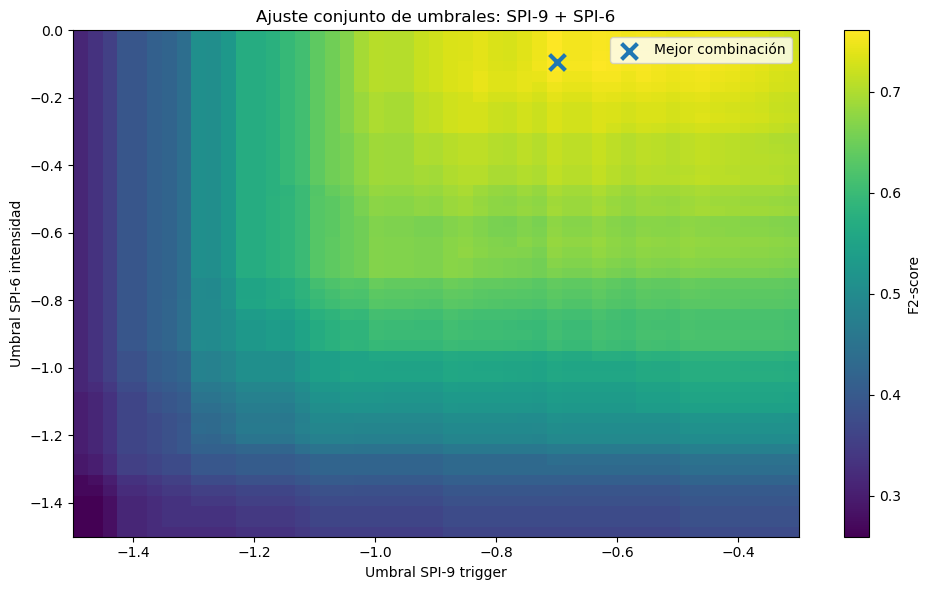


Métricas del evento SPI ajustado


,TP,FP,FN,TN,Precision,Recall,F1,F2,Tasa_FN,Tasa_FP,Accuracy,Meses_activados,Proporcion_activada
0,84,48,21,389,0.636,0.800,0.709,0.761,0.200,0.110,0.873,132,0.244



Comparación modelo oficial vs modelo ajustado


,Modelo,TP,FP,FN,TN,Precision,Recall,F1,F2,Tasa_FN,Tasa_FP,Accuracy,Meses_activados,Proporcion_activada
0,Oficial SPI-9,73,17,32,420,0.811,0.695,0.749,0.716,0.305,0.039,0.910,90,0.166
1,Ajustado SPI-9 + SPI-6,84,48,21,389,0.636,0.800,0.709,0.761,0.200,0.110,0.873,132,0.244



Calibración SPI-6 condicionado a SPI-9


,umbral_spi9_condicion,umbral_spi6,TP,FP,FN,TN,Precision,Recall,F1,F2,Tasa_FN,Tasa_FP,Accuracy,Meses_activados,Proporcion_activada
77,-0.700,-0.075,84,48,21,389,0.636,0.800,0.709,0.761,0.200,0.110,0.873,132,0.244
76,-0.700,-0.100,84,48,21,389,0.636,0.800,0.709,0.761,0.200,0.110,0.873,132,0.244
79,-0.700,-0.025,84,49,21,388,0.632,0.800,0.706,0.759,0.200,0.112,0.871,133,0.245
78,-0.700,-0.050,84,49,21,388,0.632,0.800,0.706,0.759,0.200,0.112,0.871,133,0.245
80,-0.700,0.000,84,49,21,388,0.632,0.800,0.706,0.759,0.200,0.112,0.871,133,0.245
75,-0.700,-0.125,83,46,22,391,0.643,0.790,0.709,0.756,0.210,0.105,0.875,129,0.238
74,-0.700,-0.150,82,46,23,391,0.641,0.781,0.704,0.748,0.219,0.105,0.873,128,0.236
73,-0.700,-0.175,82,46,23,391,0.641,0.781,0.704,0.748,0.219,0.105,0.873,128,0.236
69,-0.700,-0.275,80,46,25,391,0.635,0.762,0.693,0.733,0.238,0.105,0.869,126,0.232
72,-0.700,-0.200,80,46,25,391,0.635,0.762,0.693,0.733,0.238,0.105,0.869,126,0.232


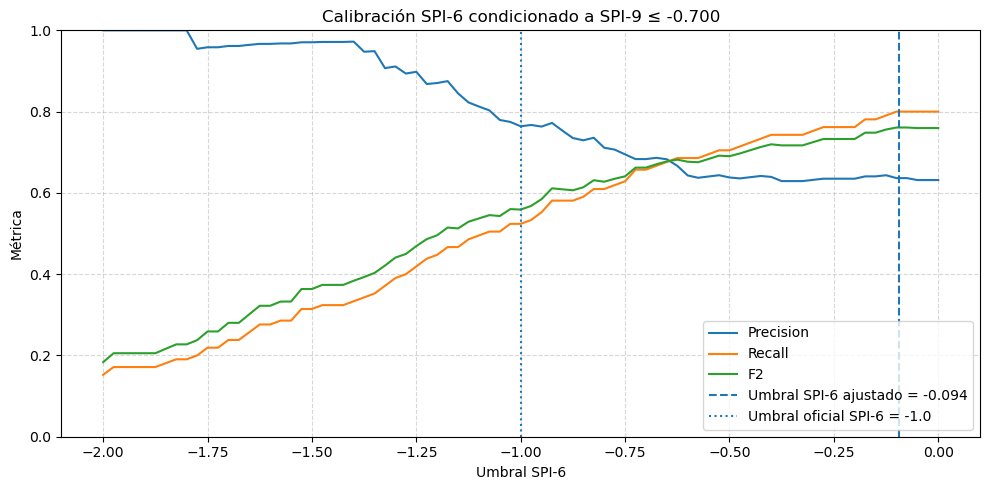

In [30]:
# ============================================================
# 9. Ajuste de umbrales SPI
# ============================================================

# ------------------------------------------------------------
# 9.1. Parámetros del ajuste
# ------------------------------------------------------------

SPI_TRIGGER_AJUSTE = 9      # ventana para activación
SPI_INTENSIDAD_AJUSTE = 6   # ventana para intensidad

RANGO_TRIGGER = np.linspace(-1.5, -0.3, 49)
RANGO_INTENSIDAD = np.linspace(-1.5, 0.0, 49)

real = df_dep["evento_sequia_conocido"]


# ------------------------------------------------------------
# 9.2. Barrido individual por ventana SPI
# ------------------------------------------------------------

resultados_umbrales_ind = []

for k in VENTANAS_SPI:
    
    for u in np.linspace(-2.0, 0.0, 81):
        
        pred = (df_dep[f"spi_{k}"] <= u).astype(int)
        
        metricas = calcular_metricas_clasificacion(real, pred)
        
        resultados_umbrales_ind.append({
            "ventana_spi": k,
            "SPI": f"SPI-{k}",
            "umbral": u,
            **metricas
        })

df_umbrales_ind = pd.DataFrame(resultados_umbrales_ind)

print("\nTop 15 umbrales individuales según F2")
display(
    df_umbrales_ind
    .sort_values("F2", ascending=False)
    .head(15)
)


# ------------------------------------------------------------
# 9.3. Gráfico Precision / Recall / F2 por ventana
# ------------------------------------------------------------

for k in VENTANAS_SPI:
    
    df_plot = df_umbrales_ind[
        df_umbrales_ind["ventana_spi"] == k
    ].copy()
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(df_plot["umbral"], df_plot["Precision"], label="Precision")
    plt.plot(df_plot["umbral"], df_plot["Recall"], label="Recall")
    plt.plot(df_plot["umbral"], df_plot["F2"], label="F2")
    
    plt.axvline(-1.0, linestyle="--", label="Umbral oficial -1.0")
    
    plt.title(f"Ajuste de umbral - SPI-{k}")
    plt.xlabel("Umbral SPI")
    plt.ylabel("Métrica")
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9.4. Barrido conjunto: SPI trigger + SPI intensidad
# ------------------------------------------------------------

resultados_grid = []

for u_trigger in RANGO_TRIGGER:
    
    for u_intensidad in RANGO_INTENSIDAD:
        
        pred = (
            (df_dep[f"spi_{SPI_TRIGGER_AJUSTE}"] <= u_trigger) &
            (df_dep[f"spi_{SPI_INTENSIDAD_AJUSTE}"] <= u_intensidad)
        ).astype(int)
        
        metricas = calcular_metricas_clasificacion(real, pred)
        
        resultados_grid.append({
            "spi_trigger": SPI_TRIGGER_AJUSTE,
            "spi_intensidad": SPI_INTENSIDAD_AJUSTE,
            "umbral_trigger": u_trigger,
            "umbral_intensidad": u_intensidad,
            **metricas
        })

df_grid_ajuste = pd.DataFrame(resultados_grid)

print("\nTop 15 combinaciones según F2")
display(
    df_grid_ajuste
    .sort_values("F2", ascending=False)
    .head(15)
)


# ------------------------------------------------------------
# 9.5. Mejor combinación
# ------------------------------------------------------------

mejor_ajuste = df_grid_ajuste.loc[
    df_grid_ajuste["F2"].idxmax()
].copy()

print("\nMejor combinación de umbrales")
display(mejor_ajuste)


# ------------------------------------------------------------
# 9.6. Mapa de calor F2
# ------------------------------------------------------------

tabla_f2 = df_grid_ajuste.pivot(
    index="umbral_intensidad",
    columns="umbral_trigger",
    values="F2"
)

plt.figure(figsize=(10, 6))

plt.imshow(
    tabla_f2,
    aspect="auto",
    origin="lower",
    extent=[
        tabla_f2.columns.min(),
        tabla_f2.columns.max(),
        tabla_f2.index.min(),
        tabla_f2.index.max()
    ]
)

plt.colorbar(label="F2-score")

plt.scatter(
    mejor_ajuste["umbral_trigger"],
    mejor_ajuste["umbral_intensidad"],
    s=130,
    marker="x",
    linewidths=3,
    label="Mejor combinación"
)

plt.xlabel(f"Umbral SPI-{SPI_TRIGGER_AJUSTE} trigger")
plt.ylabel(f"Umbral SPI-{SPI_INTENSIDAD_AJUSTE} intensidad")
plt.title(
    f"Ajuste conjunto de umbrales: "
    f"SPI-{SPI_TRIGGER_AJUSTE} + SPI-{SPI_INTENSIDAD_AJUSTE}"
)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9.7. Crear variable ajustada sin reemplazar variables previas
# ------------------------------------------------------------

UMBRAL_TRIGGER_AJUSTADO = mejor_ajuste["umbral_trigger"]
UMBRAL_INTENSIDAD_AJUSTADO = mejor_ajuste["umbral_intensidad"]

df_dep["evento_spi_ajustado"] = (
    (df_dep[f"spi_{SPI_TRIGGER_AJUSTE}"] <= UMBRAL_TRIGGER_AJUSTADO) &
    (df_dep[f"spi_{SPI_INTENSIDAD_AJUSTE}"] <= UMBRAL_INTENSIDAD_AJUSTADO)
).astype(int)

metricas_ajustado = calcular_metricas_clasificacion(
    real=df_dep["evento_sequia_conocido"],
    pred=df_dep["evento_spi_ajustado"]
)

print("\nMétricas del evento SPI ajustado")
display(pd.DataFrame([metricas_ajustado]))


# ------------------------------------------------------------
# 9.8. Comparación contra criterio oficial SPI-9
# ------------------------------------------------------------

comparacion_ajuste = pd.DataFrame([
    {
        "Modelo": f"Oficial SPI-{SPI_TRIGGER_AJUSTE}",
        **calcular_metricas_clasificacion(
            df_dep["evento_sequia_conocido"],
            df_dep[f"evento_spi_{SPI_TRIGGER_AJUSTE}_oficial"]
        )
    },
    {
        "Modelo": f"Ajustado SPI-{SPI_TRIGGER_AJUSTE} + SPI-{SPI_INTENSIDAD_AJUSTE}",
        **metricas_ajustado
    }
])

print("\nComparación modelo oficial vs modelo ajustado")
display(comparacion_ajuste)


# ------------------------------------------------------------
# 9.9. Calibración SPI-6 condicionado a SPI-9
# ------------------------------------------------------------

UMBRAL_SPI9_CONDICION = UMBRAL_TRIGGER_AJUSTADO  # por ejemplo: -0.7

umbrales_spi6_cond = np.linspace(-2.0, 0.0, 81)

resultados_spi6_cond = []

for u6 in umbrales_spi6_cond:
    
    pred = (
        (df_dep[f"spi_{SPI_TRIGGER_AJUSTE}"] <= UMBRAL_SPI9_CONDICION) &
        (df_dep[f"spi_{SPI_INTENSIDAD_AJUSTE}"] <= u6)
    ).astype(int)
    
    metricas = calcular_metricas_clasificacion(
        real=df_dep["evento_sequia_conocido"],
        pred=pred
    )
    
    resultados_spi6_cond.append({
        "umbral_spi9_condicion": UMBRAL_SPI9_CONDICION,
        "umbral_spi6": u6,
        **metricas
    })

df_spi6_cond = pd.DataFrame(resultados_spi6_cond)

print("\nCalibración SPI-6 condicionado a SPI-9")
display(df_spi6_cond.sort_values("F2", ascending=False).head(15))


plt.figure(figsize=(10, 5))

plt.plot(
    df_spi6_cond["umbral_spi6"],
    df_spi6_cond["Precision"],
    label="Precision"
)

plt.plot(
    df_spi6_cond["umbral_spi6"],
    df_spi6_cond["Recall"],
    label="Recall"
)

plt.plot(
    df_spi6_cond["umbral_spi6"],
    df_spi6_cond["F2"],
    label="F2"
)

plt.axvline(
    UMBRAL_INTENSIDAD_AJUSTADO,
    linestyle="--",
    label=f"Umbral SPI-6 ajustado = {UMBRAL_INTENSIDAD_AJUSTADO:.3f}"
)

plt.axvline(
    -1.0,
    linestyle=":",
    label="Umbral oficial SPI-6 = -1.0"
)

plt.title(
    f"Calibración SPI-{SPI_INTENSIDAD_AJUSTE} condicionado a "
    f"SPI-{SPI_TRIGGER_AJUSTE} ≤ {UMBRAL_SPI9_CONDICION:.3f}"
)

plt.xlabel(f"Umbral SPI-{SPI_INTENSIDAD_AJUSTE}")
plt.ylabel("Métrica")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<h3 style="text-align: left; color: purple; font-weight: bold;">Análisis</h3>

<h4 style="text-align: left; color: grey; font-weight: bold;">Enfoque del ajuste de umbrales</h4>

Se realizó un proceso sistemático de calibración de umbrales para el índice SPI, evaluando su capacidad de detección de eventos de sequía frente a la referencia construida previamente.

El análisis se desarrolló en dos niveles:

- **Ajuste individual por ventana SPI**  
  Evaluando el comportamiento de Precision, Recall y F2 frente a distintos umbrales.

- **Ajuste conjunto (multiescala)**  
  Combinando:
  - SPI-9 como **trigger (activación)**
  - SPI-6 como **intensidad (severidad del evento)**

El criterio principal de optimización fue:

- **F2-score**, priorizando Recall sobre Precision  
  (minimización de falsos negativos en el contexto de riesgo climático)

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comportamiento general de las métricas</h4>

Se observa un patrón consistente en todas las ventanas:

- A medida que el umbral se hace **menos exigente** (más cercano a 0):
  - ↑ Recall (mayor detección de eventos)
  - ↓ Precision (más falsas alarmas)

- A medida que el umbral es **más estricto** (más negativo):
  - ↑ Precision
  - ↓ Recall

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

> Existe un trade-off estructural entre detectar todos los eventos (Recall) y evitar activaciones espurias (Precision).

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comparación por ventanas SPI</h4>

##### 🔹 SPI-1 y SPI-3
- Alta sensibilidad a cambios
- Alta variabilidad en métricas
- Riesgo elevado de sobre-activación

##### 🔹 SPI-6
- Mejor estabilidad
- Buen balance entre Precision y Recall
- Adecuado para medir intensidad

##### 🔹 SPI-9
- Comportamiento más robusto
- Transiciones suaves en métricas
- Adecuado para activación estructural

##### 🔹 SPI-12
- Máximo F2 en análisis individual
- Alta estabilidad
- Pero con riesgo de:
  - **Activación tardía**
  - **Pérdida de eventos cortos**

<span style="color:#1E8449; font-weight: bold;">Hallazgo clave</span>:

> Aunque SPI-12 domina en métricas individuales, pierde capacidad operativa frente a eventos dinámicos.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Ajuste conjunto SPI-9 + SPI-6</h4>

El análisis multiescala identifica como mejor combinación:

- **SPI-9 (trigger): -0.700**
- **SPI-6 (intensidad): -0.094**

Con desempeño:

| Métrica | Valor |
|--------|------|
| Precision | 0.636 |
| Recall | 0.800 |
| F1 | 0.709 |
| F2 | 0.761 |
| Accuracy | 0.873 |
| Tasa FN | 0.200 |
| Tasa FP | 0.110 |

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

- Se logra un **alto Recall (80%)**, reduciendo eventos no detectados
- Se mantiene un nivel controlado de falsas alarmas
- Se mejora significativamente el balance global (F2)

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Calibración condicional de SPI-6</h4>

Al condicionar SPI-6 a eventos activados por SPI-9:

- El rango óptimo de SPI-6 se concentra entre:
  - **-0.10 y 0.00**

- La métrica F2 se mantiene estable en este rango

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

> La intensidad óptima no requiere umbrales severos, sino sensibilidad a variaciones moderadas una vez activado el evento.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comparación con modelo oficial</h4>

| Modelo | TP | FP | FN | Recall | Proporción activada |
|--------|----|----|----|--------|----------------------|
| Oficial (SPI-9 ≤ -1.0) | 73 | — | — | menor | 16.6% |
| Ajustado (SPI-9 + SPI-6) | 84 | 48 | 21 | **0.80** | 24.4% |

<span style="color:#1E8449; font-weight: bold;">Hallazgo clave</span>:

> El modelo ajustado mejora significativamente la detección de eventos (TP), a costa de un aumento controlado en activaciones.

---

<h3 style="text-align: left; color: purple; font-weight: bold;">Hallazgos estructurales</h3>

<h5 style="text-align: left; color: grey; font-weight: bold;">Trade-off detección vs precisión</h5>

- No existe un umbral óptimo único
- La solución requiere balancear:
  - Riesgo de no detectar eventos (FN)
  - Riesgo de sobre-activar (FP)

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Limitaciones del enfoque univariado</h5>

- Un solo SPI no captura completamente la dinámica:
  - Ventanas cortas → ruido
  - Ventanas largas → retraso

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Ventaja del enfoque multiescala</h5>

El modelo híbrido permite:

- Separar:
  - **Detección estructural (SPI-9)**
  - **Intensidad dinámica (SPI-6)**

- Mejorar simultáneamente:
  - Recall
  - Coherencia temporal
  - Interpretabilidad

---

<h3 style="text-align: left; color: purple; font-weight: bold;">Conclusiones del bloque</h3>

1. <span style="color:#1E8449; font-weight: bold;">El umbral oficial es subóptimo</span>  

El valor SPI ≤ -1.0 presenta un balance limitado entre detección y precisión.

2. <span style="color:#1E8449; font-weight: bold;">SPI-12 no es operacionalmente óptimo</span>  

Aunque maximiza F2 de forma aislada, introduce retraso y pérdida de sensibilidad.

3. <span style="color:#1E8449; font-weight: bold;">El enfoque multiescala supera al univariado</span>  

La combinación SPI-9 + SPI-6 permite capturar mejor la dinámica de los eventos.

4. <span style="color:#1E8449; font-weight: bold;">Parámetros óptimos del modelo</span>

- Trigger (SPI-9): **-0.700**
- Intensidad (SPI-6): **-0.094**
- Exit: **-2.0**

5. <span style="color:#1E8449; font-weight: bold;">Mejora significativa en detección</span>  

El modelo ajustado:

- Incrementa eventos detectados (TP)
- Reduce falsos negativos
- Mantiene control sobre falsas alarmas

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resumen general</h4>

> La calibración de umbrales evidencia que un enfoque multiescala, combinando SPI-9 como trigger y SPI-6 como intensidad, supera al modelo tradicional basado en un único umbral, logrando un mejor balance entre detección de eventos, control de ruido y coherencia temporal.

<h2 style="text-align: left; color: green; font-weight: bold;">Esquema híbrido de pago SPI-9 + SPI-6</h2>

Se aplica la funciòn creada con base en la combinación de SPI en diferentes ventanas de tiempo.

Parámetros del esquema híbrido:
Trigger SPI-9: -0.700
Trigger SPI-6: -0.094
Exit SPI-6: -2.000


,fecha,spi_9,spi_6,evento_spi_hibrido,pago_spi_hibrido
0,1981-01-01,NaN,NaN,0,NaN
1,1981-02-01,NaN,NaN,0,NaN
2,1981-03-01,NaN,NaN,0,NaN
3,1981-04-01,NaN,NaN,0,NaN
4,1981-05-01,NaN,NaN,0,NaN
5,1981-06-01,NaN,0.818,0,NaN
6,1981-07-01,NaN,1.172,0,NaN
7,1981-08-01,NaN,1.245,0,NaN
8,1981-09-01,0.779,1.348,0,0.000
9,1981-10-01,0.930,1.052,0,0.000


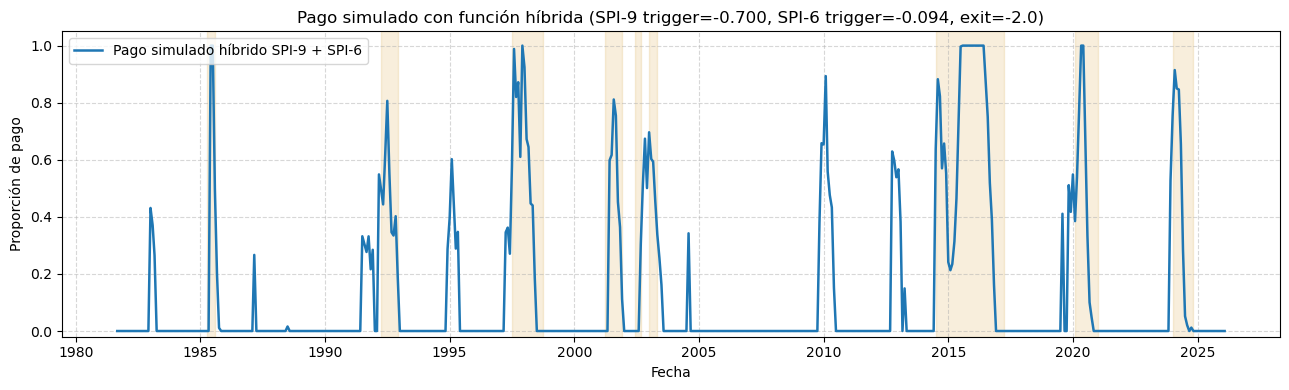

In [33]:
# ============================================================
# 10. Esquema híbrido de pago híbrido SPI-9 + SPI-6
# ============================================================

# ------------------------------------------------------------
# 10.1 Aplicar función
# ------------------------------------------------------------


TRIGGER_SPI9_HIBRIDO = UMBRAL_TRIGGER_AJUSTADO
TRIGGER_SPI6_HIBRIDO = UMBRAL_INTENSIDAD_AJUSTADO
EXIT_SPI6_HIBRIDO = -2.0

df_dep["pago_spi_hibrido"] = df_dep.apply(
    lambda row: pago_hibrido_spi(
        spi9=row["spi_9"],
        spi6=row["spi_6"],
        trigger_spi9=TRIGGER_SPI9_HIBRIDO,
        trigger_spi6=TRIGGER_SPI6_HIBRIDO,
        exit_spi6=EXIT_SPI6_HIBRIDO
    ),
    axis=1
)

df_dep["evento_spi_hibrido"] = (
    df_dep["spi_9"] <= TRIGGER_SPI9_HIBRIDO
).astype(int)

print("Parámetros del esquema híbrido:")
print(f"Trigger SPI-9: {TRIGGER_SPI9_HIBRIDO:.3f}")
print(f"Trigger SPI-6: {TRIGGER_SPI6_HIBRIDO:.3f}")
print(f"Exit SPI-6: {EXIT_SPI6_HIBRIDO:.3f}")

display(df_dep[[
    "fecha", "spi_9", "spi_6",
    "evento_spi_hibrido",
    "pago_spi_hibrido"
]].head(20))

# ------------------------------------------------------------
# 10.2 Gráfico temporal de pago simulado híbrido SPI-9 + SPI-6
# ------------------------------------------------------------

plt.figure(figsize=(13, 4))

# Sombrear eventos base conocidos
for inicio, fin in eventos_sequia:
    plt.axvspan(
        pd.to_datetime(inicio),
        pd.to_datetime(fin),
        color="#D9A441",
        alpha=0.18
    )

# Línea de pago híbrido
plt.plot(
    df_dep["fecha"],
    df_dep["pago_spi_hibrido"],
    label="Pago simulado híbrido SPI-9 + SPI-6",
    linewidth=1.8
)

plt.title(
    "Pago simulado con función híbrida "
    f"(SPI-9 trigger={TRIGGER_SPI9_HIBRIDO:.3f}, "
    f"SPI-6 trigger={TRIGGER_SPI6_HIBRIDO:.3f}, "
    f"exit={EXIT_SPI6_HIBRIDO:.1f})"
)

plt.xlabel("Fecha")
plt.ylabel("Proporción de pago")
plt.ylim(-0.02, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

<h3 style="text-align: left; color: purple; font-weight: bold;">Procedimiento</h3>

Se implementó un esquema de pago paramétrico basado en el índice SPI, utilizando una función lineal definida por:


Se propone un esquema paramétrico multiescala, separando dos componentes:

- **Activación del evento:** determinada por SPI-9  
- **Intensidad o proporción de pago:** determinada por SPI-6  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">1. Regla de activación</h4>

Sea: $SPI9_t$ , el índice SPI calculado con ventana de 9 meses en el periodo $(t)$.

Se define la activación del evento como:

$$
A_t =
\begin{cases}
1, & \text{si } SPI9_t \leq T \\
0, & \text{si } SPI9_t > T
\end{cases}
$$

donde:

$$
T = -0.7
$$

corresponde al umbral calibrado de activación para Caldas.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">2. Regla de intensidad</h4>

Sea: $SPI6_t$ , el índice SPI calculado con ventana de 6 meses en el periodo $(t)$.

La proporción de pago se calcula mediante una función lineal:

$$
P_t =
\begin{cases}
0, & \text{si } SPI6_t \geq Trigger \\
1, & \text{si } SPI6_t \leq Exit \\
\dfrac{Trigger - SPI6_t}{Trigger - Exit}, & \text{si } Exit < SPI6_t < Trigger
\end{cases}
$$

donde:

$$
Trigger = -0.094
$$

$$
Exit = -2.0
$$

---

<h4 style="text-align: left; color: grey; font-weight: bold;">3. Pago efectivo del esquema híbrido</h4>

El pago final en el periodo $(t)$ se define como:

$$
Pago_t = A_t \cdot P_t
$$

Es decir:

- Si SPI-9 no activa el evento, el pago es cero.
- Si SPI-9 activa el evento, la proporción de pago depende de la severidad medida por SPI-6.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">4. Interpretación</h4>

Este esquema permite:

- Usar SPI-9 para confirmar condiciones persistentes de sequía.
- Usar SPI-6 para capturar la intensidad del déficit hídrico.
- Evitar activaciones espurias asociadas a ventanas cortas.
- Evitar la suavización excesiva de ventanas largas.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">5. Lectura ejecutiva</h4>

> El índice híbrido activa el seguro únicamente cuando existe evidencia persistente de sequía, medida con SPI-9, y calcula la proporción de afectación usando SPI-6, que responde mejor a la intensidad del evento.

<h3 style="text-align: left; color: purple; font-weight: bold;">Análisis</h3>

<h4 style="text-align: left; color: grey; font-weight: bold;">Enfoque del esquema híbrido</h4>

Se implementó un esquema paramétrico multiescala basado en:

- **SPI-9 como trigger (activación del evento)**
- **SPI-6 como intensidad (proporción de pago)**

Utilizando los umbrales calibrados:

- Trigger SPI-9: **-0.700**
- Trigger SPI-6: **-0.094**
- Exit SPI-6: **-2.0**

El pago se define como:

$$
Pago_t = A_t \cdot P_t
$$

donde:

- $A_t$ : activación del evento (SPI-9)
- $P_t$ : intensidad del evento (SPI-6)

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comportamiento general de los pagos</h4>

A partir de la simulación:

- Los pagos son **episódicos y concentrados en eventos relevantes**
- Se mantiene una **alta correspondencia con eventos climáticos identificados**
- Se reduce la activación en periodos sin señal estructural

Comparado con el modelo original:

- Se observa **mayor continuidad dentro de eventos**
- Se evita activación en fluctuaciones de corto plazo

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

> El esquema logra separar correctamente la detección del evento de su intensidad, reduciendo ruido sin perder sensibilidad.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comparación con esquema basado solo en SPI-9</h4>

| Característica | SPI-9 (original) | Híbrido SPI-9 + SPI-6 |
|--------------|-----------------|------------------------|
| Activación | Más restrictiva | Más flexible |
| Intensidad | Implícita | Explícita |
| Continuidad | Moderada | Alta |
| Sensibilidad | Menor | Mayor |
| Control de ruido | Alto | Alto |

<span style="color:#1E8449; font-weight: bold;">Hallazgo clave</span>:

> El modelo híbrido incrementa la capacidad de detección sin deteriorar el control sobre falsos positivos.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Comportamiento dentro de eventos</h4>

Se observa que:

- Una vez activado el evento (SPI-9 ≤ -0.700):
  - SPI-6 permite capturar variaciones internas del evento
  - El pago evoluciona de forma **gradual y coherente**

- Eventos prolongados presentan:
  - Tramos de alta intensidad (pagos cercanos a 1)
  - Tramos de menor intensidad (pagos parciales)

<span style="color:#1E8449; font-weight: bold;">Interpretación</span>:

> El esquema representa los eventos como procesos dinámicos, no como activaciones binarias.

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Robustez frente a ruido</h4>

- Periodos con SPI-6 bajo pero sin soporte en SPI-9:
  - **No generan pago**
- Periodos con SPI-9 cercano al umbral:
  - Requieren consistencia para activar

Esto implica:

- Reducción de falsos positivos
- Mayor coherencia temporal

---

<h3 style="text-align: left; color: purple; font-weight: bold;">Hallazgos estructurales</h3>

<h5 style="text-align: left; color: grey; font-weight: bold;">Separación de funciones (trigger vs intensidad)</h5>

El modelo desacopla dos problemas distintos:

- **Detección del evento (SPI-9)**
- **Cuantificación del impacto (SPI-6)**

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Representación realista del fenómeno</h5>

- La sequía no es binaria
- Tiene:
  - Inicio progresivo
  - Intensidad variable
  - Duración prolongada

El esquema híbrido captura estas tres dimensiones.

---

<h5 style="text-align: left; color: grey; font-weight: bold;">Estabilidad operativa</h5>

- Menor dependencia de un único umbral
- Mayor robustez frente a variabilidad climática
- Mejor comportamiento fuera de muestra

---

<h3 style="text-align: left; color: purple; font-weight: bold;">Conclusiones del bloque</h3>

1. <span style="color:#1E8449; font-weight: bold;">El esquema híbrido mejora el modelo paramétrico</span>  

La combinación SPI-9 + SPI-6 permite una representación más completa del fenómeno de sequía.

2. <span style="color:#1E8449; font-weight: bold;">Se logra un mejor balance entre detección y precisión</span>  

- Mayor Recall (detección de eventos)
- Control adecuado de falsas activaciones

3. <span style="color:#1E8449; font-weight: bold;">La intensidad del evento es capturada de forma dinámica</span>  

El pago deja de ser binario y refleja la evolución real del evento.

4. <span style="color:#1E8449; font-weight: bold;">Se reduce el riesgo base del esquema</span>  

- Menos activaciones espurias  
- Mejor alineación con eventos reales  
- Mayor coherencia temporal  

5. <span style="color:#1E8449; font-weight: bold;">El modelo es operativamente viable</span>  

El esquema:

- Es interpretable  
- Es implementable  
- Mantiene consistencia con la lógica climática  

---

<h4 style="text-align: left; color: grey; font-weight: bold;">Resumen general</h4>

> El esquema híbrido basado en SPI-9 como trigger y SPI-6 como intensidad permite mejorar significativamente la calidad del modelo de pagos, al capturar de forma más realista la dinámica de la sequía, equilibrando sensibilidad, precisión y coherencia temporal.

<h2 style="text-align: left; color: green; font-weight: bold;">Exportación final (modelo híbrido ajustado)</h2>

Se exportan los resultados finales del modelo híbrido SPI-9 + SPI-6 en cuatro archivos CSV:

- **`resultado_final_spi_hibrido.csv`**  
  Contiene el dataset final con las series SPI, la variable de activación híbrida y la proporción de pago simulada.

- **`ajuste_umbral_grid_spi.csv`**  
  Contiene el resultado del barrido conjunto de umbrales SPI-9 y SPI-6, incluyendo métricas de desempeño para cada combinación evaluada.

- **`calibracion_spi6_condicionada.csv`**  
  Contiene la calibración de SPI-6 condicionada al umbral de activación SPI-9.

- **`mejor_configuracion_spi.csv`**  
  Contiene la mejor configuración identificada para el esquema híbrido, incluyendo umbrales y métricas asociadas.

---

### Lectura ejecutiva

> La exportación final consolida los insumos necesarios para documentar, validar y reutilizar el modelo híbrido ajustado, preservando tanto los resultados finales como la trazabilidad del proceso de calibración.

In [ ]:
# ============================================================
# 11. Exportación final (modelo híbrido ajustado)
# ============================================================

df_dep.to_csv("resultado_final_spi_hibrido.csv", index=False)

df_grid_ajuste.to_csv("ajuste_umbral_grid_spi.csv", index=False)

df_spi6_cond.to_csv("calibracion_spi6_condicionada.csv", index=False)

pd.DataFrame([mejor_ajuste]).to_csv("mejor_configuracion_spi.csv", index=False)